In [1]:
import pandas as pd
import numpy as np
from numpy import unique
from numpy import where
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler
from scipy.stats.mstats import winsorize

from sklearn.cluster import DBSCAN
from matplotlib import pyplot

%matplotlib inline

In [2]:
data = pd.read_csv("data/CC GENERAL.csv")

## Data Exploration

In [3]:
data.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
data.shape

(8950, 18)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [6]:
# Numerical features statistics
data.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [7]:
# number of unique values in each column
data.nunique()

CUST_ID                             8950
BALANCE                             8871
BALANCE_FREQUENCY                     43
PURCHASES                           6203
ONEOFF_PURCHASES                    4014
INSTALLMENTS_PURCHASES              4452
CASH_ADVANCE                        4323
PURCHASES_FREQUENCY                   47
ONEOFF_PURCHASES_FREQUENCY            47
PURCHASES_INSTALLMENTS_FREQUENCY      47
CASH_ADVANCE_FREQUENCY                54
CASH_ADVANCE_TRX                      65
PURCHASES_TRX                        173
CREDIT_LIMIT                         205
PAYMENTS                            8711
MINIMUM_PAYMENTS                    8636
PRC_FULL_PAYMENT                      47
TENURE                                 7
dtype: int64

In [8]:
# number of unique values in each column
data[data.duplicated()]

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE


### Check missing values

In [9]:
# check NULLs in each column
missing_percentage = data.isna().mean().sort_values(ascending=False)
missing_count = data.isna().sum().sort_values(ascending=False)

pd.DataFrame({'missing_percentage': missing_percentage, 'missing_count': missing_count})

,missing_percentage,missing_count
MINIMUM_PAYMENTS,0.034972,313
CREDIT_LIMIT,0.000112,1
CUST_ID,0.000000,0
BALANCE,0.000000,0
PRC_FULL_PAYMENT,0.000000,0
PAYMENTS,0.000000,0
PURCHASES_TRX,0.000000,0
CASH_ADVANCE_TRX,0.000000,0
CASH_ADVANCE_FREQUENCY,0.000000,0
PURCHASES_INSTALLMENTS_FREQUENCY,0.000000,0


'CREDIT_LIMIT' have only one missing value, let's check it out

In [10]:
credit_limit_null = data['CREDIT_LIMIT'].isnull()
data[credit_limit_null]

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
5203,C15349,18.400472,0.166667,0.0,0.0,0.0,186.853063,0.0,0.0,0.0,0.166667,1,0,NaN,9.040017,14.418723,0.0,6


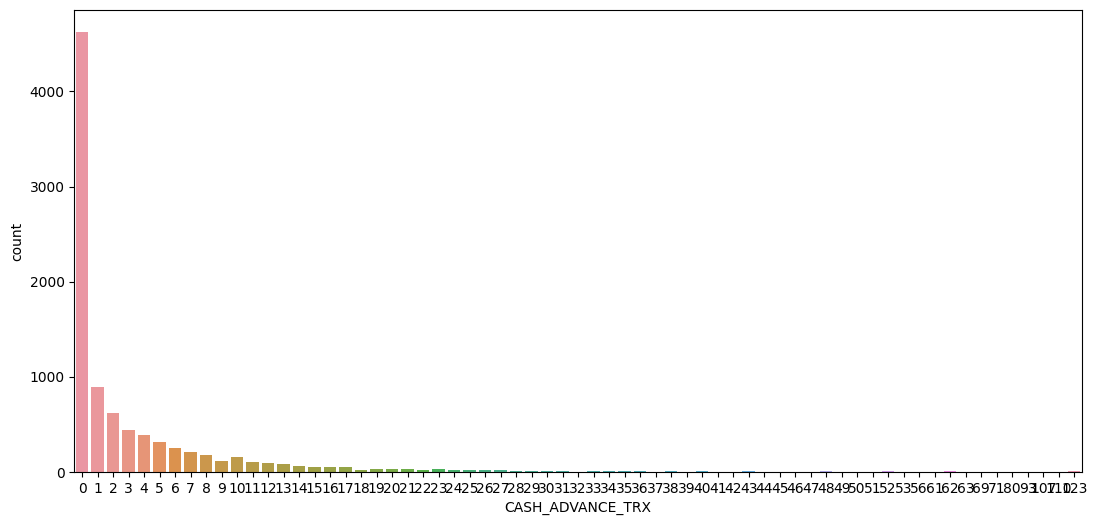

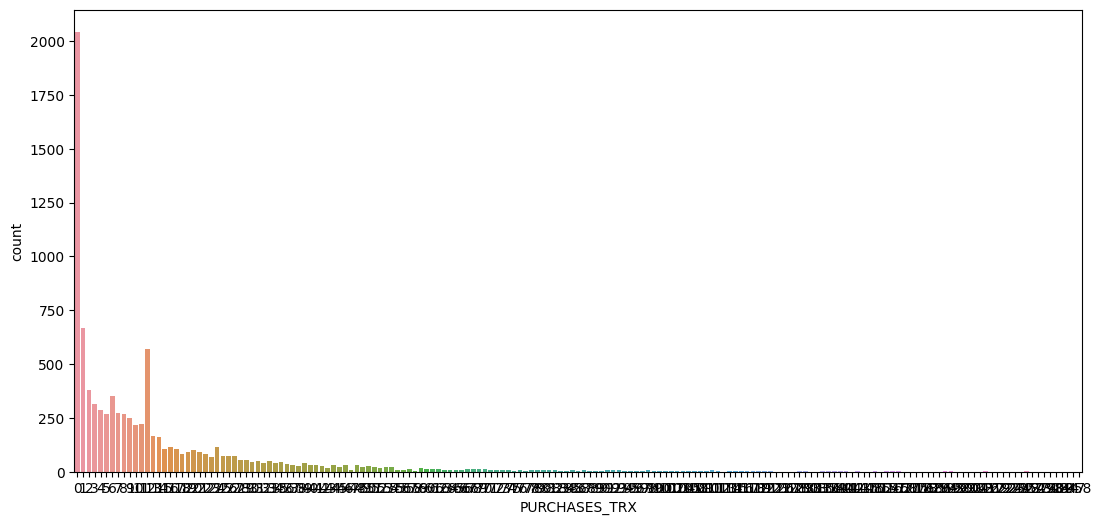

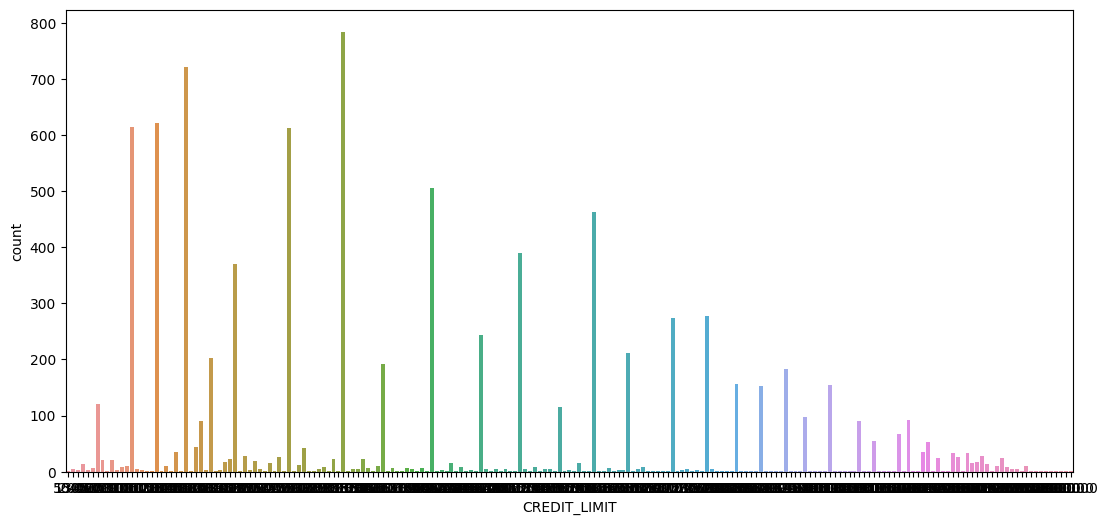

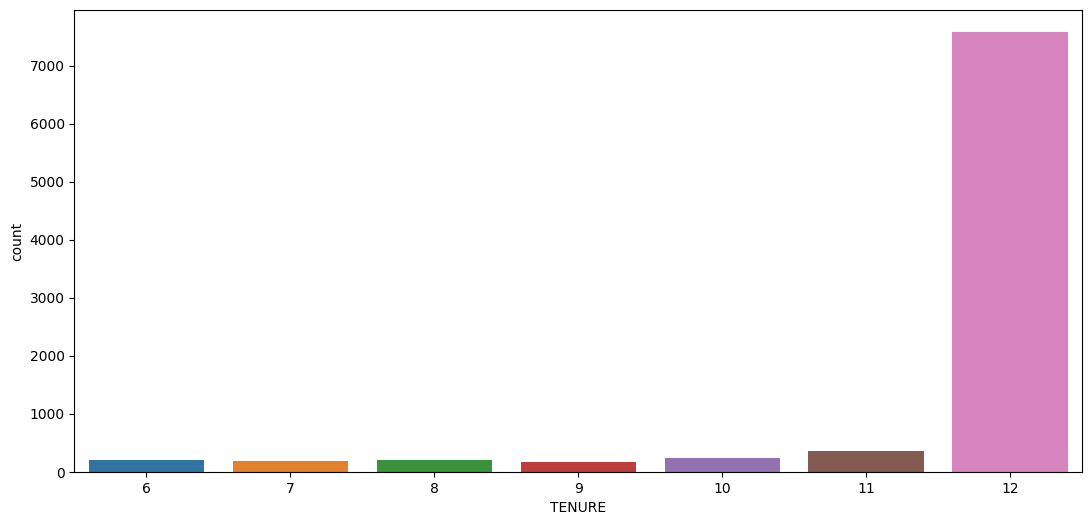

In [11]:
# Plot frequency for discrete columns
discrete_features = ['CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'TENURE']
for discrete_feature in discrete_features:
    fig = plt.figure(figsize = (13, 6))
    sns.countplot(x = discrete_feature, data = data)

* 'CASH_ADVANCE_TRX', and 'PURCHASES_TRX' are highly skewed with a peak
* most frequenct value in 'TENURE' is 12

some features are heavily skewed. As a result, further inspection for finding outliers is a must

In [12]:
numeric_fetures = data.select_dtypes(include=np.number).columns.tolist()
data_numeric = data[numeric_fetures]
data_numeric.shape

(8950, 17)

## Handle Outliers


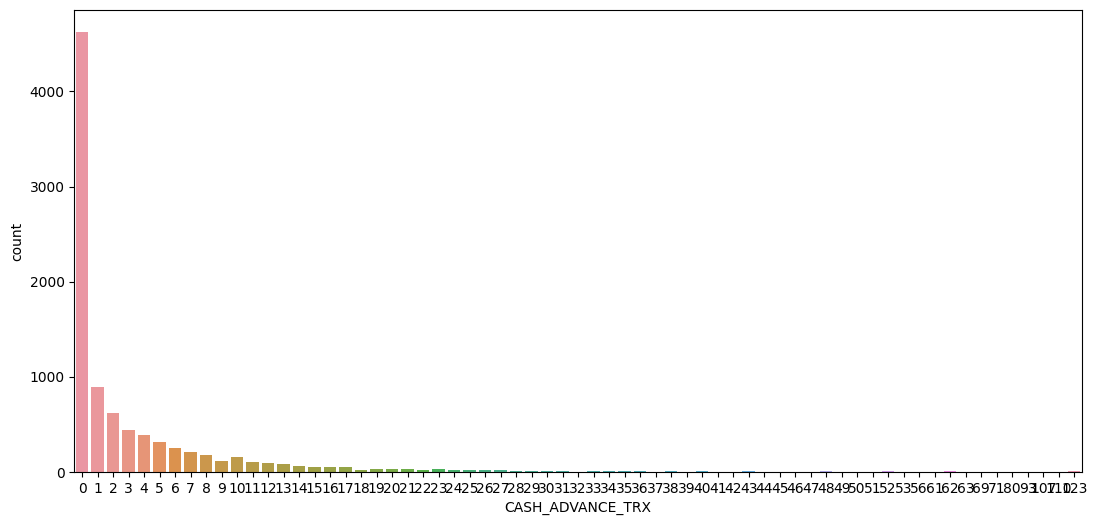

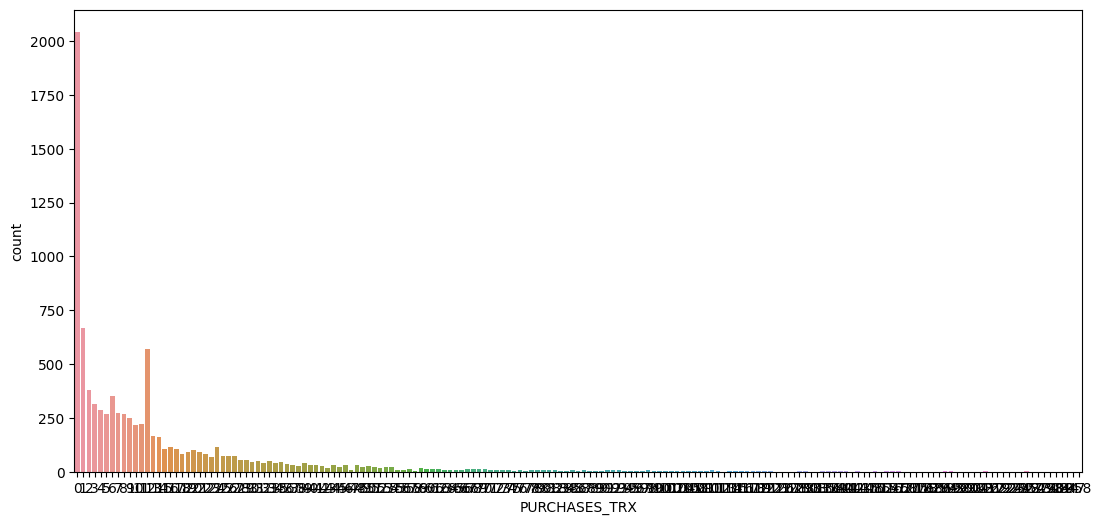

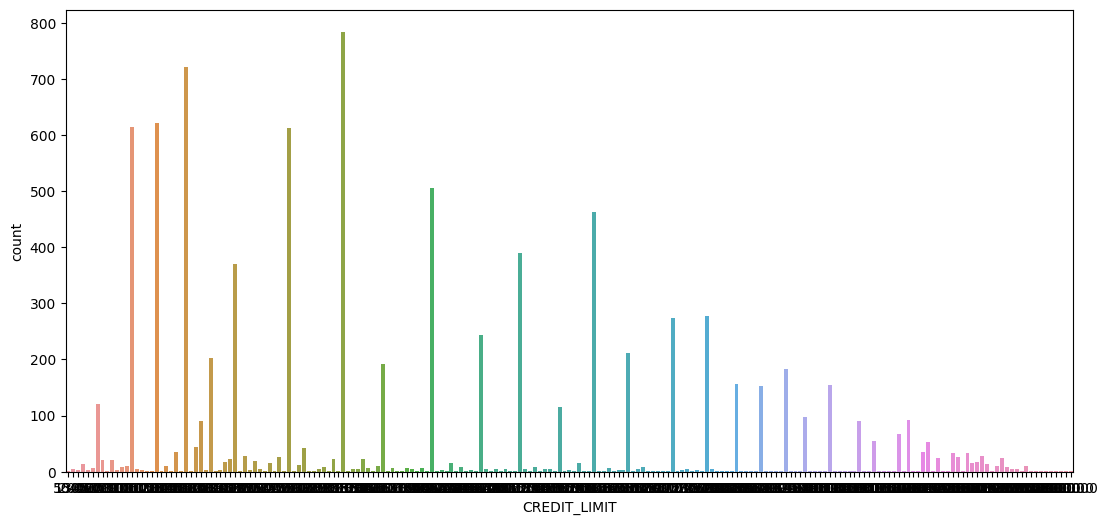

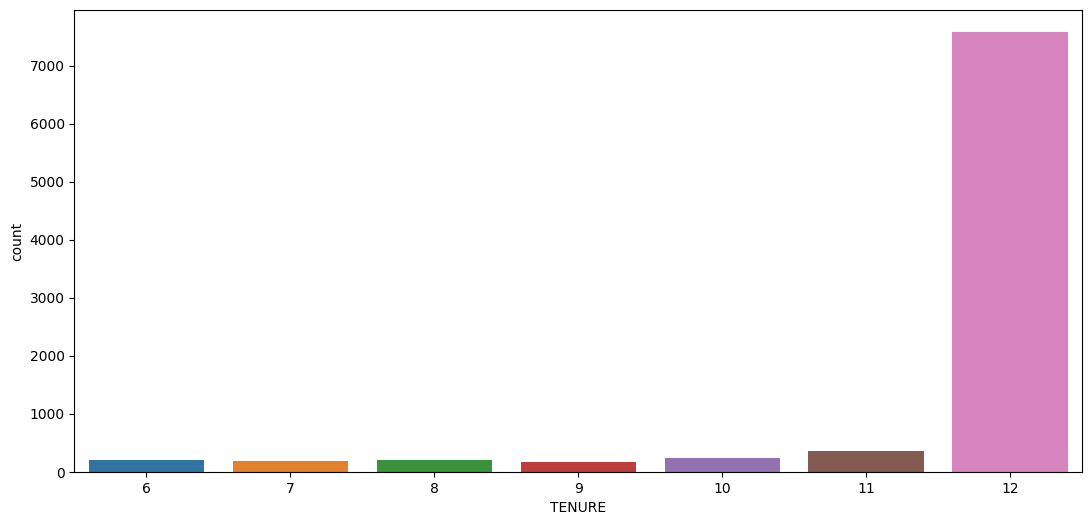

In [13]:
# Plot frequency for discrete columns
discrete_features = ['CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'TENURE']
for discrete_feature in discrete_features:
    fig = plt.figure(figsize = (13, 6))
    sns.countplot(x = discrete_feature, data = data)

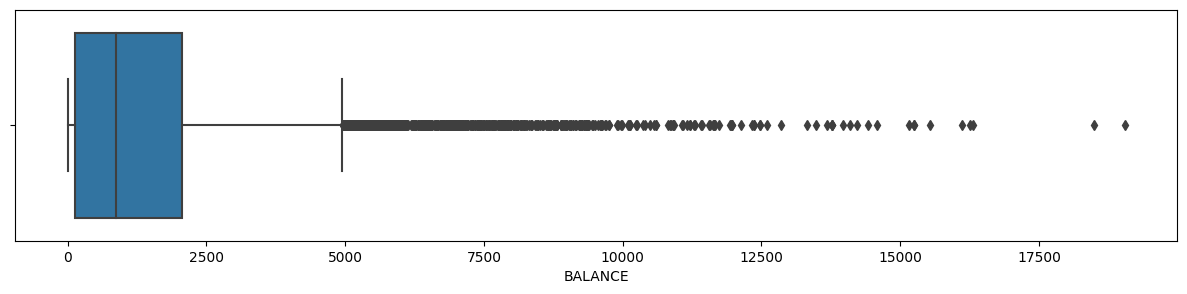

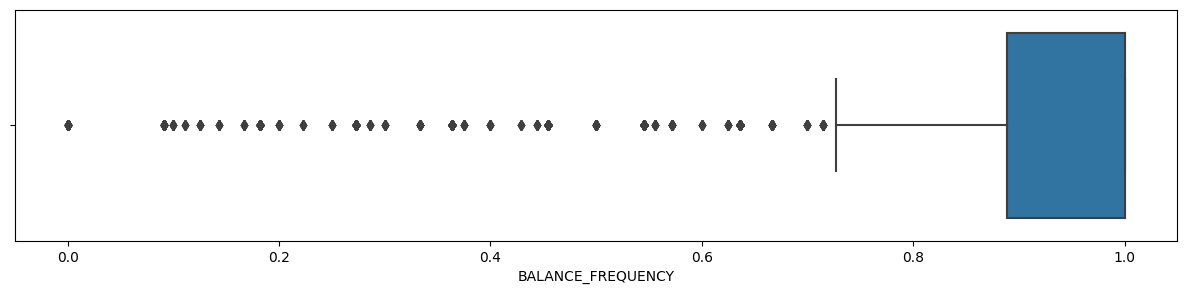

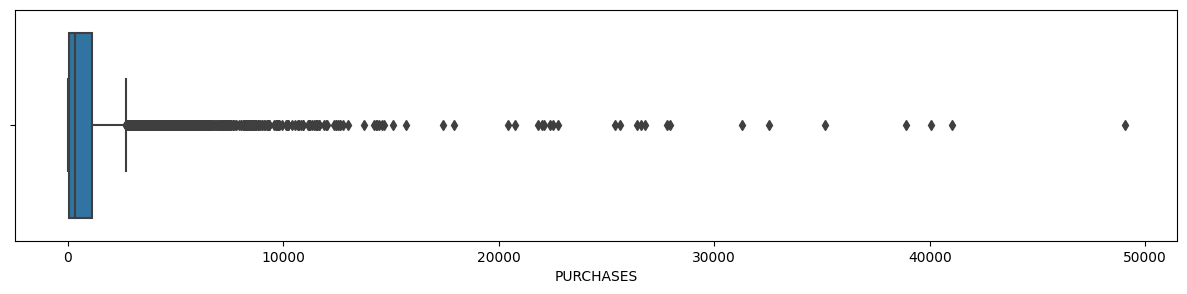

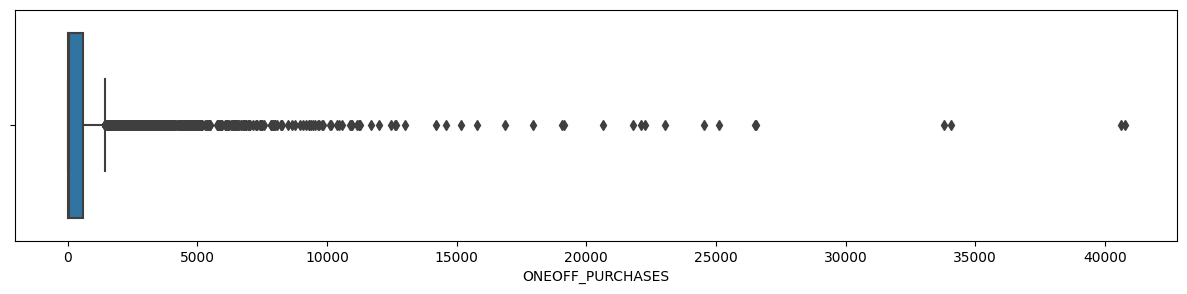

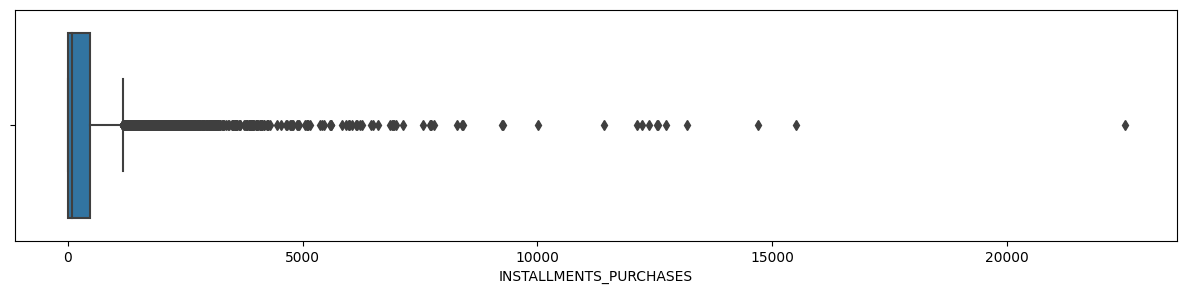

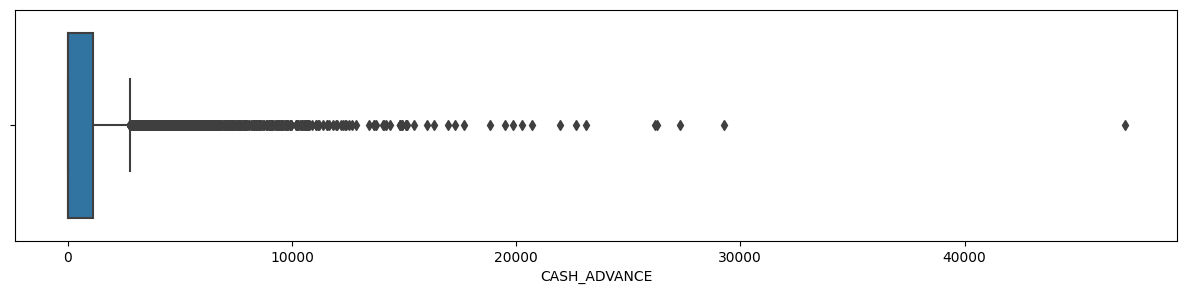

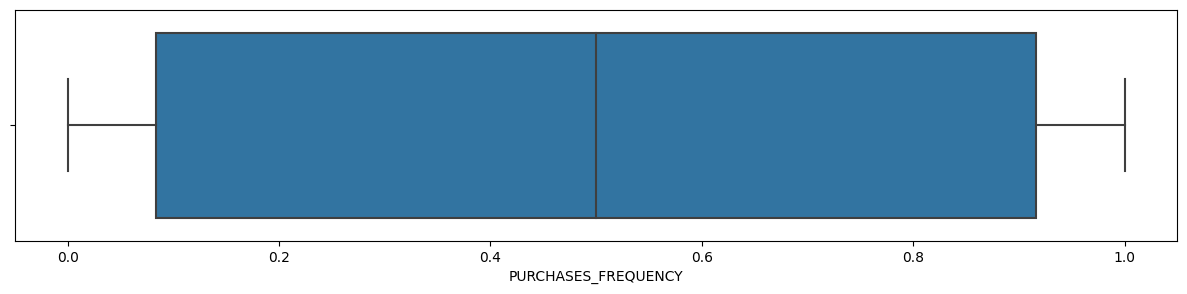

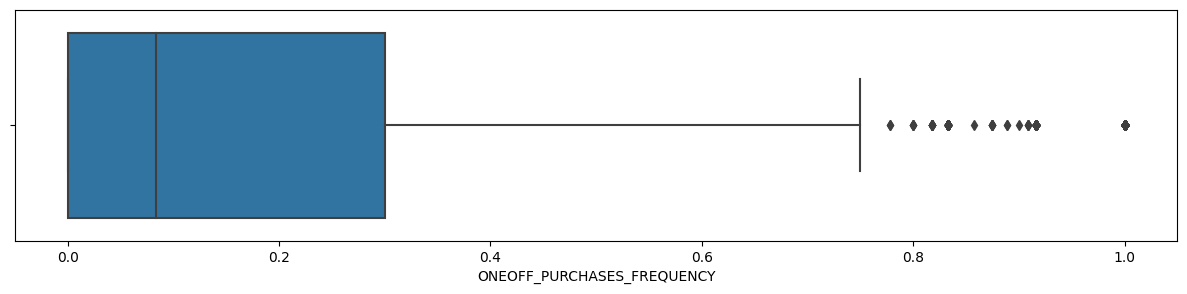

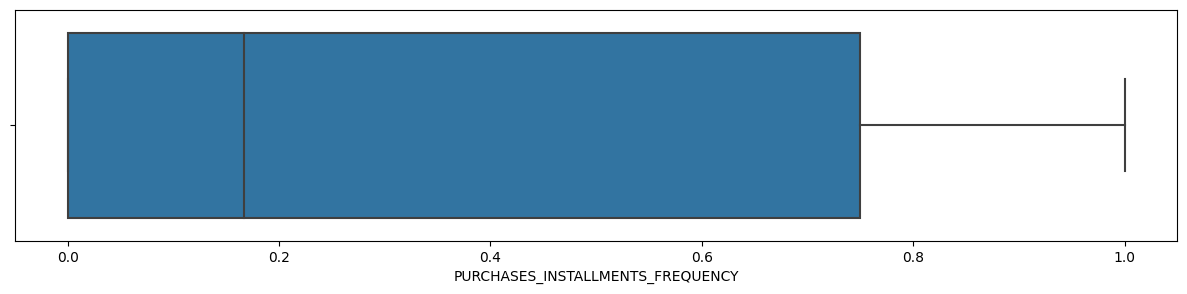

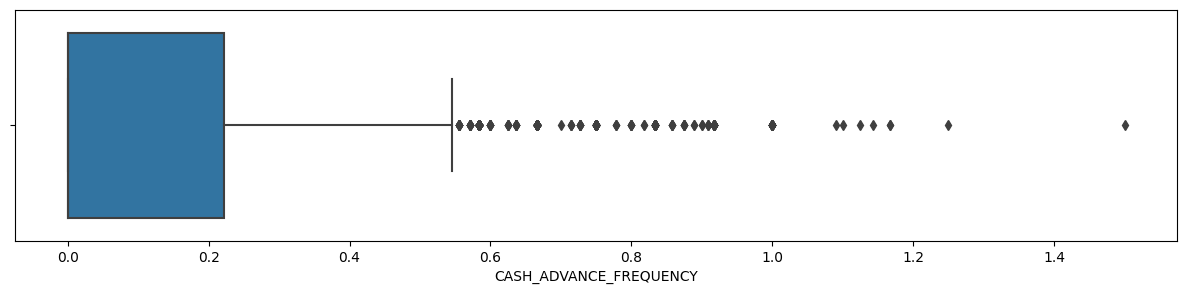

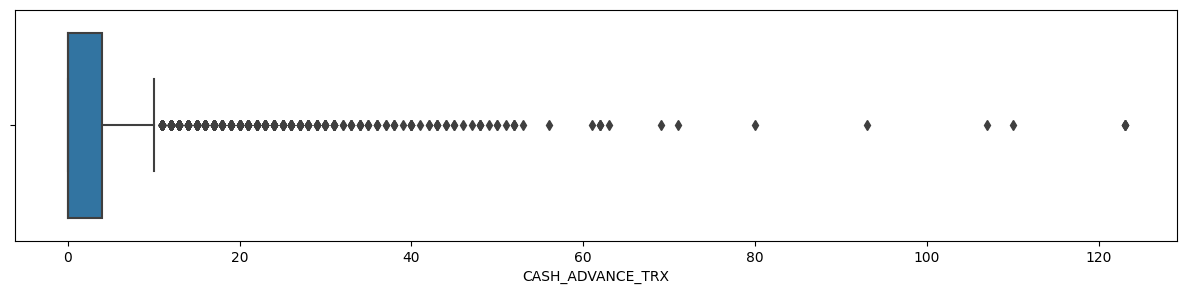

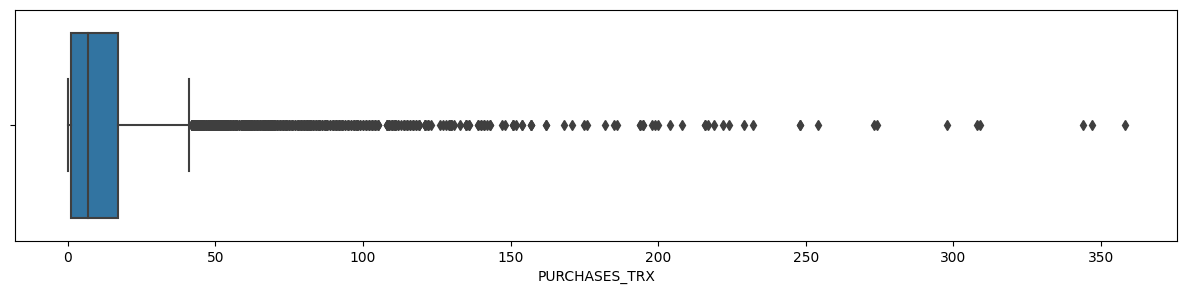

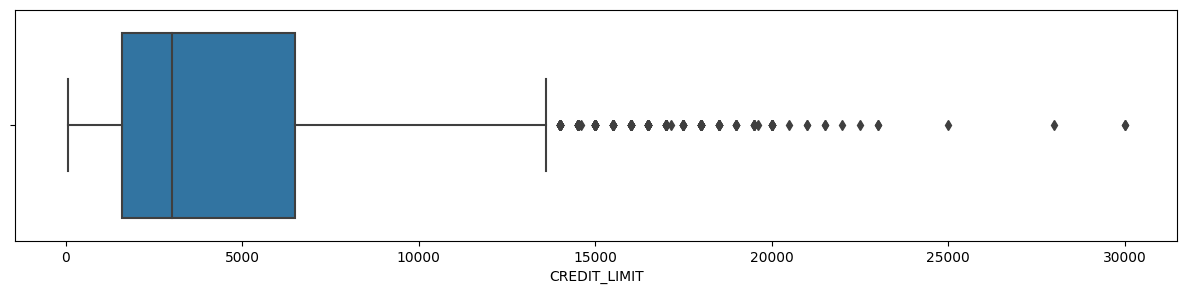

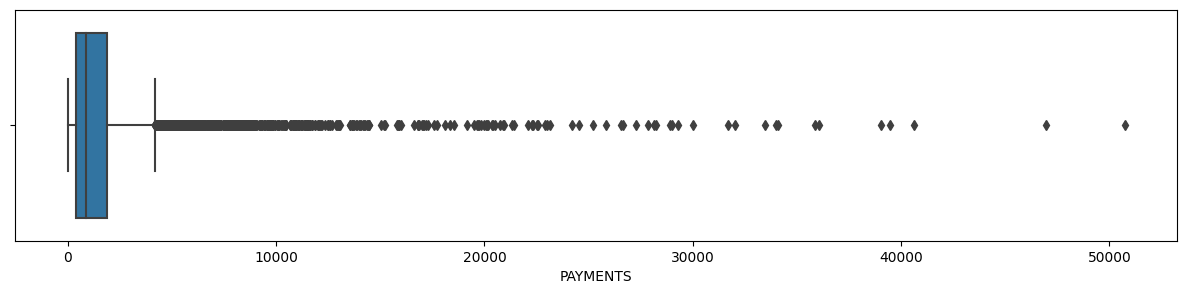

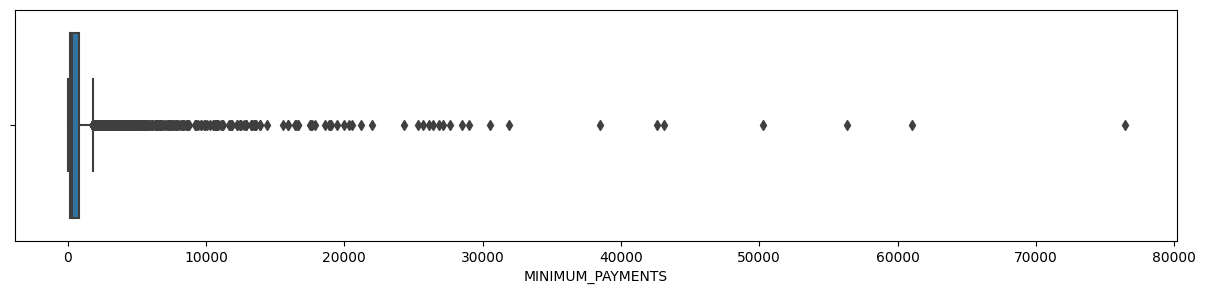

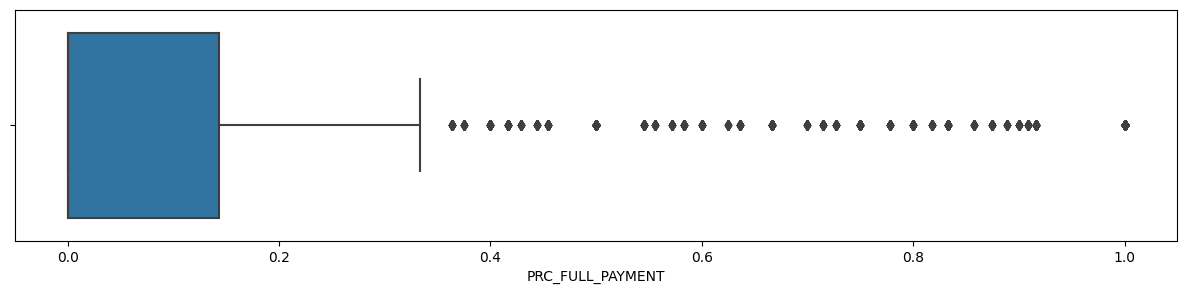

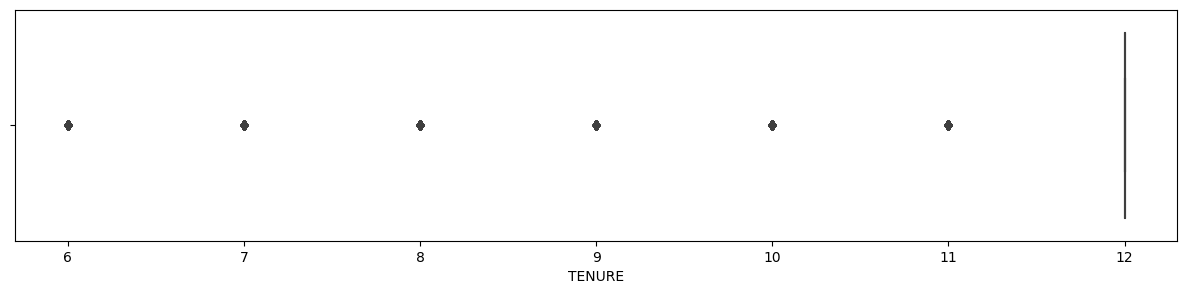

In [14]:
# for col in numeric_fetures:
#     try:
#         fig = plt.figure(figsize = (12, 3), dpi = 120)
#         sns.boxplot(x = data[col], data = data)
#     except:
#         continue
# plt.show()
for col in numeric_fetures:
    fig = plt.figure(figsize = (15, 3))
    sns.boxplot(x = data[col], data = data)
plt.show()

#### Box Plots Interpretations
* BALANCE : There might be some noises as there are outliers which have values more than 17500.

* BALANCE_FREQUENCY : There are some values equal to zero, however the distance is not significant.

* PURCHASES : Values more than 30000 are outliers, but there is one near 50000 that is suspicious to be a noise.

* ONEOFF_PURCHASES : There are some outliers more than 33000.

* INSTALLMENT_PURCHASES : A sample with a value more than 20000 might be a noise.

* CASH_ADVANCE : A value that is more than 40000 is an outlier and should be inspected.

* PURCHASES_FREQUENCY : Values in this column are distributed with balance, and no outlier is on the plot.

* ONEOFF_PURCHASES_FREQUENCY : None of the values is as far from the rest as a noise might be.

* PURCHASES_INSTALLMENT_FREQUENCY : Also in this column there is a balance in distribution of the samples, and there is not any outlier.

* CASH_ADVANCE_FREQUENCY : However the value more than 14 seems like an outlier, but there is a low chance of being a noise.

* CASH_ADVANCE_TRX : Most of the values in this column are near "0". So, it should be inspected in relation with other features.

* PURCHASES_TRX : Just like CASH_ADVANCE_TRX, an analysis in relation with other features is needed.

* CREDIT_LIMIT : Samples equal or above 25000 should be inspected.

* PAYMENTS : There are number of outliers with values above 45000.

* MINIMUM_PAYMENTS : Values more than 35000 should be reviewed carefully.

* PRC_FULL_PAYMENT : There is not any outlier or noise.

* TENURE : Values on this column are not continuous.

In [15]:
def column_percentile(data, feature):
    # Calculate the 0.95 and 0.05 percentiles of the "sample" column
    p95 = data[feature].quantile(0.95)
    p05 = data[feature].quantile(0.05)

    # Filter the samples that are higher than the 0.95 percentile and less than the 0.05 percentile
    df_filtered = data[(data[feature] > p95) | (data[feature] < p05)]

    print("Count:", len(df_filtered))
    print("Percentage:", len(df_filtered)/data.shape[0])
    return df_filtered

In [16]:
column_percentile(data, 'BALANCE')

Count: 896
Percentage: 0.10011173184357541


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
15,C10016,6886.213231,1.000000,1611.70,0.00,1611.70,2301.491267,0.500000,0.000000,0.500000,0.166667,4,11,8000.0,1993.439277,2109.906490,0.0,12
21,C10022,6369.531318,1.000000,6359.95,5910.04,449.91,229.028245,1.000000,0.916667,1.000000,0.333333,6,92,11250.0,2077.959051,1659.775075,0.0,12
28,C10029,7152.864372,1.000000,387.05,204.55,182.50,2236.145259,0.666667,0.166667,0.416667,0.833333,16,8,10500.0,1601.448347,1648.851345,0.0,12
30,C10031,12136.219960,1.000000,3038.01,1013.20,2024.81,3183.583301,1.000000,0.166667,1.000000,0.500000,10,64,13000.0,4230.323491,3292.015030,0.0,12
32,C10033,6732.823064,1.000000,324.95,324.95,0.00,1189.533753,0.083333,0.083333,0.000000,0.166667,3,3,10500.0,1720.118876,2506.745366,0.0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8907,C19148,2.559461,0.571429,116.10,0.00,116.10,0.000000,0.857143,0.000000,0.714286,0.000000,0,6,1500.0,256.642179,66.289561,0.5,7
8921,C19162,3.417407,0.500000,57.42,0.00,57.42,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1500.0,68.462579,20.714869,0.0,6
8924,C19165,7.336804,0.333333,74.00,74.00,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,1,3000.0,214.921009,44.254787,0.0,6
8941,C19182,5967.475270,0.833333,214.55,0.00,214.55,8555.409326,0.833333,0.000000,0.666667,0.666667,13,5,9000.0,966.202912,861.949906,0.0,6


In [17]:
column_percentile(data, 'BALANCE_FREQUENCY')

Count: 351
Percentage: 0.03921787709497207


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
63,C10065,7.152356,0.090909,840.00,840.0,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1600.0,0.000000,NaN,0.0,12
99,C10104,0.000000,0.000000,0.00,0.0,0.00,89.849004,0.000000,0.000000,0.000000,0.142857,1,0,3000.0,138.021428,NaN,0.0,7
103,C10108,0.624240,0.090909,389.96,0.0,389.96,0.000000,1.000000,0.000000,1.000000,0.000000,0,31,4500.0,0.000000,NaN,0.0,12
129,C10135,69.405545,0.090909,0.00,0.0,0.00,2799.714934,0.000000,0.000000,0.000000,0.083333,3,0,13000.0,0.000000,NaN,0.0,12
181,C10187,0.000000,0.000000,23.00,0.0,23.00,0.000000,0.083333,0.000000,0.083333,0.000000,0,1,5000.0,0.000000,NaN,0.0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,C18994,3.036243,0.090909,0.00,0.0,0.00,81.569379,0.000000,0.000000,0.000000,0.083333,1,0,500.0,0.000000,NaN,0.0,12
8784,C19023,4.358863,0.181818,70.00,70.0,0.00,0.000000,0.090909,0.090909,0.000000,0.000000,0,1,500.0,363.248976,75.029727,0.0,11
8793,C19033,0.275257,0.200000,0.00,0.0,0.00,328.452659,0.000000,0.000000,0.000000,0.100000,1,0,1200.0,1145.101275,39.421396,1.0,10
8854,C19095,3.833185,0.125000,45.00,45.0,0.00,0.000000,0.125000,0.125000,0.000000,0.000000,0,1,500.0,0.000000,NaN,0.0,8


In [18]:
column_percentile(data, 'PURCHASES')

Count: 448
Percentage: 0.05005586592178771


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
21,C10022,6369.531318,1.000000,6359.95,5910.04,449.91,229.028245,1.000000,0.916667,1.000000,0.333333,6,92,11250.0,2077.959051,1659.775075,0.000000,12
23,C10024,3800.151377,0.818182,4248.35,3454.56,793.79,7974.415626,1.000000,0.083333,0.916667,0.333333,13,13,9000.0,9479.043842,1425.426525,0.000000,12
57,C10059,2386.330629,1.000000,5217.62,4789.09,428.53,0.000000,0.916667,0.916667,0.500000,0.000000,0,42,7500.0,5678.729613,1311.514878,0.083333,12
71,C10074,2990.422186,0.909091,4523.27,1664.09,2859.18,27296.485760,0.666667,0.500000,0.583333,0.833333,27,33,7000.0,28232.694460,1107.030803,0.454545,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8541,C18773,3326.323283,1.000000,8209.77,2218.28,5991.49,0.000000,1.000000,0.416667,1.000000,0.000000,0,130,10000.0,1942.074765,702.905059,0.083333,12
8611,C18845,42.577756,0.909091,4061.96,4061.96,0.00,0.000000,0.916667,0.916667,0.000000,0.000000,0,35,500.0,3716.880684,92.058823,0.750000,12
8662,C18899,599.909949,1.000000,4947.32,3149.59,1797.73,0.000000,1.000000,1.000000,0.916667,0.000000,0,73,3000.0,5024.430008,218.172915,0.083333,12
8689,C18926,368.318662,0.909091,8053.95,8053.95,0.00,0.000000,0.833333,0.833333,0.000000,0.000000,0,46,2000.0,7966.582037,219.761189,0.777778,12


In [19]:
column_percentile(data, 'ONEOFF_PURCHASES')

Count: 448
Percentage: 0.05005586592178771


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
21,C10022,6369.531318,1.000000,6359.95,5910.04,449.91,229.028245,1.000000,0.916667,1.000000,0.333333,6,92,11250.0,2077.959051,1659.775075,0.000000,12
23,C10024,3800.151377,0.818182,4248.35,3454.56,793.79,7974.415626,1.000000,0.083333,0.916667,0.333333,13,13,9000.0,9479.043842,1425.426525,0.000000,12
57,C10059,2386.330629,1.000000,5217.62,4789.09,428.53,0.000000,0.916667,0.916667,0.500000,0.000000,0,42,7500.0,5678.729613,1311.514878,0.083333,12
84,C10088,1935.362486,1.000000,4915.60,4515.34,400.26,293.844792,1.000000,1.000000,0.333333,0.083333,1,50,9000.0,4921.066897,594.756686,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8662,C18899,599.909949,1.000000,4947.32,3149.59,1797.73,0.000000,1.000000,1.000000,0.916667,0.000000,0,73,3000.0,5024.430008,218.172915,0.083333,12
8689,C18926,368.318662,0.909091,8053.95,8053.95,0.00,0.000000,0.833333,0.833333,0.000000,0.000000,0,46,2000.0,7966.582037,219.761189,0.777778,12
8737,C18975,2533.618119,0.909091,5633.83,2985.92,2647.91,2451.807788,0.916667,0.500000,0.750000,0.333333,16,82,9000.0,8176.953944,602.963244,0.000000,12
8748,C18987,1042.816735,0.625000,3950.00,3950.00,0.00,0.000000,0.250000,0.250000,0.000000,0.000000,0,3,3150.0,6274.982741,303.462882,0.000000,8


In [20]:
column_percentile(data, 'CREDIT_LIMIT')

Count: 584
Percentage: 0.06525139664804469


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.00,12
18,C10019,1989.072228,1.000000,504.35,166.00,338.35,0.000000,0.666667,0.083333,0.583333,0.000000,0,9,13000.0,1720.837373,744.613395,0.00,12
30,C10031,12136.219960,1.000000,3038.01,1013.20,2024.81,3183.583301,1.000000,0.166667,1.000000,0.500000,10,64,13000.0,4230.323491,3292.015030,0.00,12
85,C10089,134.917202,1.000000,1247.80,1247.80,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,22,16500.0,1275.229436,171.357189,1.00,12
87,C10092,8181.251131,1.000000,2258.01,1318.78,939.23,5251.228934,1.000000,0.750000,1.000000,0.750000,21,60,13500.0,3021.575846,2074.581541,0.00,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8898,C19139,379.288635,0.714286,550.00,50.00,500.00,388.818230,0.571429,0.142857,0.571429,0.142857,2,6,500.0,509.404913,531.988210,0.00,7
8899,C19140,4.817213,0.285714,0.00,0.00,0.00,38.627907,0.000000,0.000000,0.000000,0.142857,1,0,500.0,51.013461,16.261428,0.00,7
8901,C19142,379.619245,0.857143,0.00,0.00,0.00,484.443319,0.000000,0.000000,0.000000,0.142857,3,0,500.0,93.745897,148.248169,0.00,7
8943,C19184,5.871712,0.500000,20.90,20.90,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,1,500.0,58.644883,43.473717,0.00,6


In [21]:
column_percentile(data, 'CASH_ADVANCE_TRX')

Count: 418
Percentage: 0.04670391061452514


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
28,C10029,7152.864372,1.000000,387.05,204.55,182.50,2236.145259,0.666667,0.166667,0.416667,0.833333,16,8,10500.0,1601.448347,1648.851345,0.000000,12
50,C10052,4931.331857,1.000000,901.42,646.07,255.35,8530.648614,0.625000,0.375000,0.250000,0.875000,37,9,12000.0,8113.297346,1012.415961,0.000000,8
71,C10074,2990.422186,0.909091,4523.27,1664.09,2859.18,27296.485760,0.666667,0.500000,0.583333,0.833333,27,33,7000.0,28232.694460,1107.030803,0.454545,12
86,C10090,7069.950386,1.000000,1603.78,1445.14,158.64,5626.004046,1.000000,0.833333,1.000000,0.750000,23,23,11000.0,4589.873897,1876.262988,0.000000,12
87,C10092,8181.251131,1.000000,2258.01,1318.78,939.23,5251.228934,1.000000,0.750000,1.000000,0.750000,21,60,13500.0,3021.575846,2074.581541,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8705,C18942,7302.672686,1.000000,0.00,0.00,0.00,10762.707760,0.000000,0.000000,0.000000,0.750000,19,0,9000.0,3824.308564,2214.506825,0.000000,12
8737,C18975,2533.618119,0.909091,5633.83,2985.92,2647.91,2451.807788,0.916667,0.500000,0.750000,0.333333,16,82,9000.0,8176.953944,602.963244,0.000000,12
8795,C19035,1478.089943,0.800000,245.01,245.01,0.00,4377.526126,0.100000,0.100000,0.000000,0.600000,22,1,2500.0,3168.779374,966.611926,0.000000,10
8858,C19099,812.934042,1.000000,50.00,50.00,0.00,2185.500596,0.142857,0.142857,0.000000,1.000000,16,1,3000.0,726.683966,127.843735,0.000000,7


### Data Pre-processing

###### Drop 'CUST_ID' column as it is not relevant to model's output

In [22]:
data.drop('CUST_ID', axis =1, inplace=True)

#### differet approaches to handle missing data

###### Drop NULLs

In [23]:
# data.drop(['MINIMUM_PAYMENTS', 'CREDIT_LIMIT'],axis=1, inplace=True)

###### Impute NULLs using KNN imputer

In [24]:
# create a KNNImputer object with k=3
imputer = KNNImputer(n_neighbors=3)

# fit and transform the imputer on the DataFrame
data = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)

###### Impute NULLs using mean()

In [25]:
# data.loc[(data['MINIMUM_PAYMENTS'].isnull()==True),'MINIMUM_PAYMENTS']=data['MINIMUM_PAYMENTS'].mean()
# data.loc[(data['CREDIT_LIMIT'].isnull()==True),'CREDIT_LIMIT']=data['CREDIT_LIMIT'].mean()

###### Replace NULLs with 0

In [26]:
# # replace all occurrences of NaN with 0
# data = data.replace(np.nan, 0)

In [27]:
numeric_fetures = data.select_dtypes(include=np.number).columns.tolist()
data_numeric = data[numeric_fetures]
data_numeric.shape

(8950, 17)

### Handle Outliers

1. Keep them without handling

2. Drop them

In [28]:
# for feature in data.columns.to_list():
#     data = data[np.abs(data[feature] - data[feature].mean()) <= (3 * data[feature].std())]


3. Winsorize

In [29]:
# # winsorize the values in column to the 95th percentile
# for feature in data.columns.to_list():
#     data[feature] = winsorize(data[feature], limits=[None, 0.05])

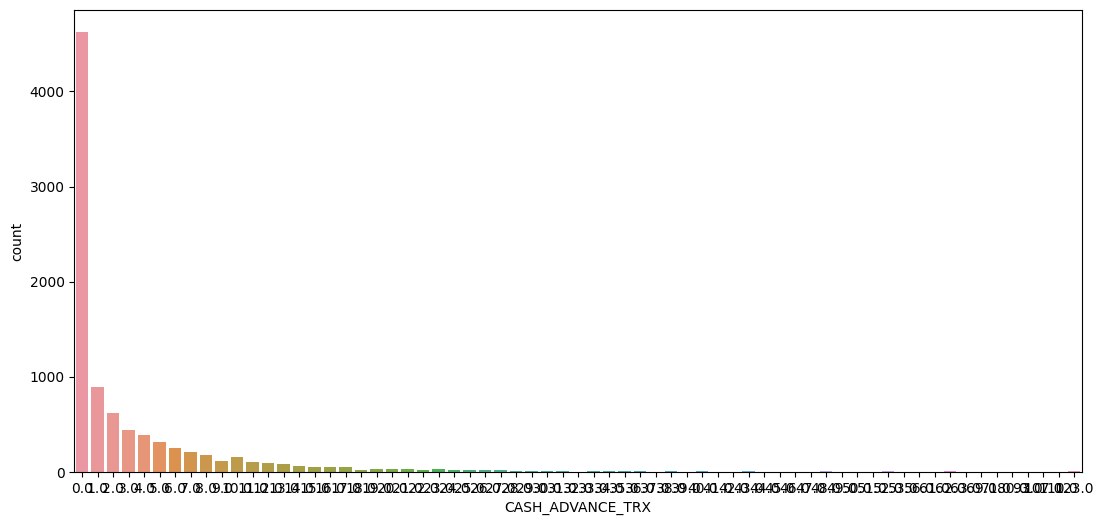

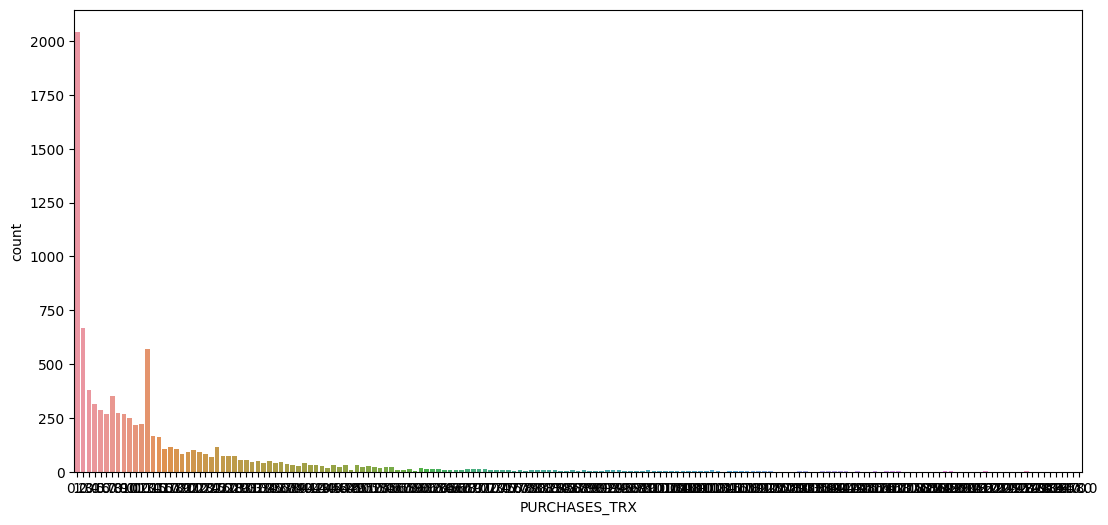

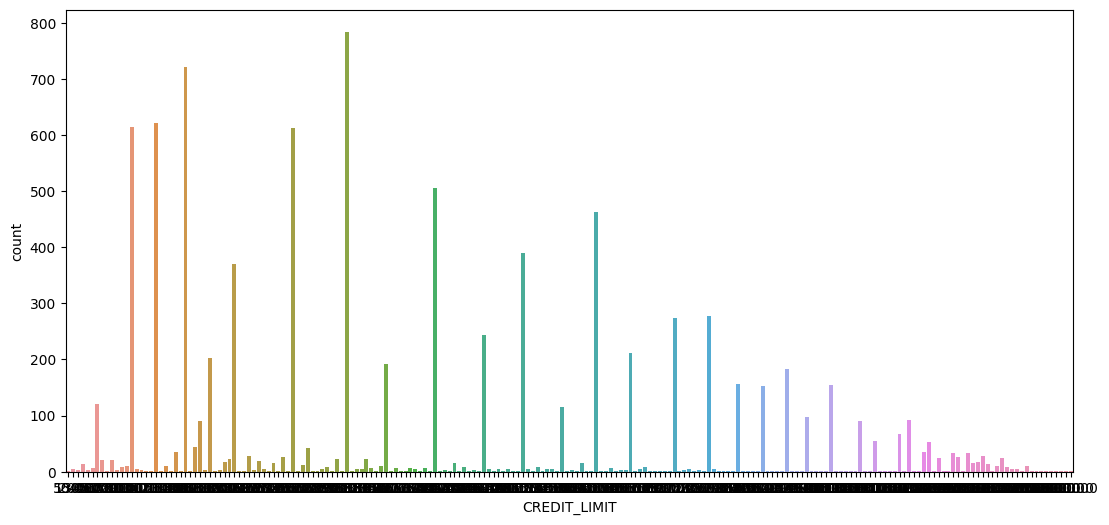

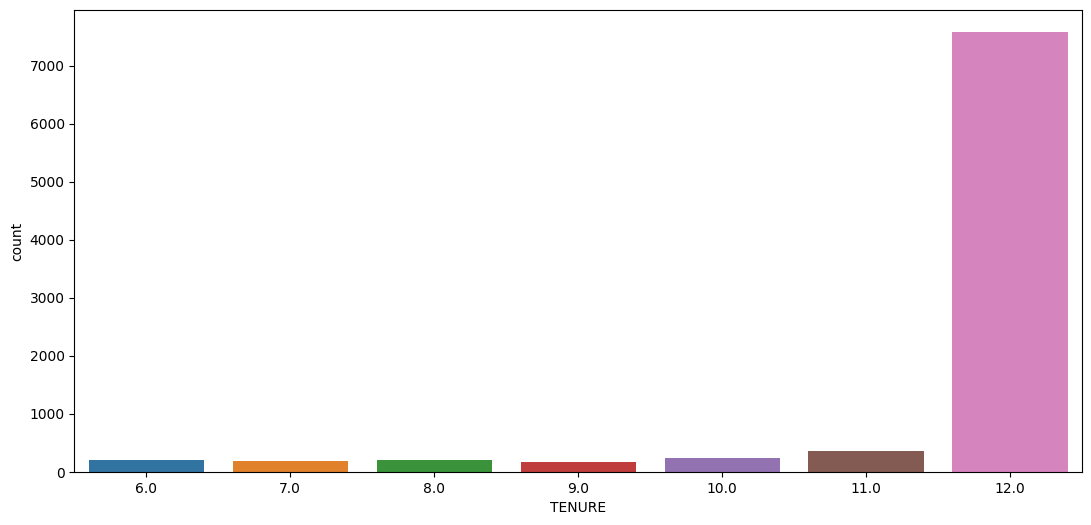

In [30]:
# Plot frequency for discrete columns
discrete_features = ['CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'TENURE']
for discrete_feature in discrete_features:
    fig = plt.figure(figsize = (13, 6))
    sns.countplot(x = discrete_feature, data = data)

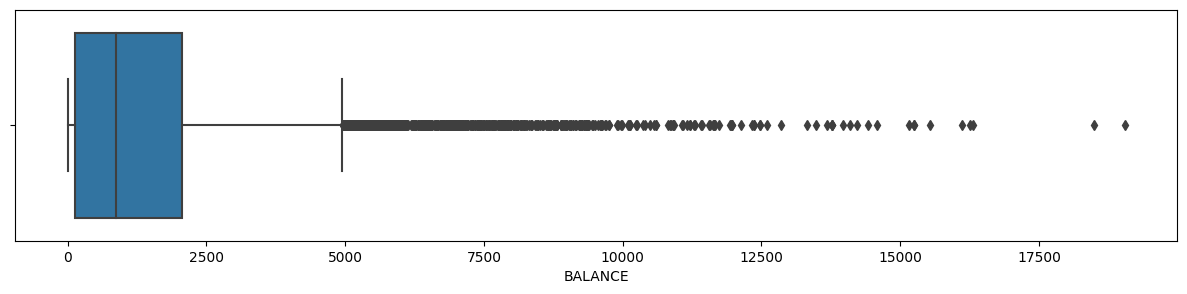

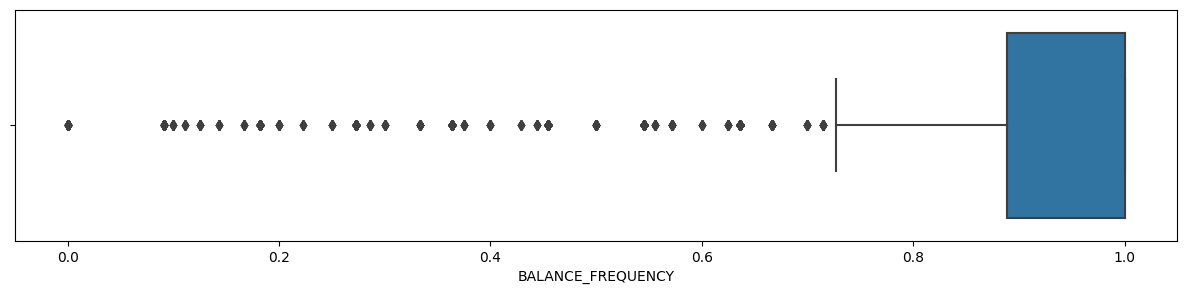

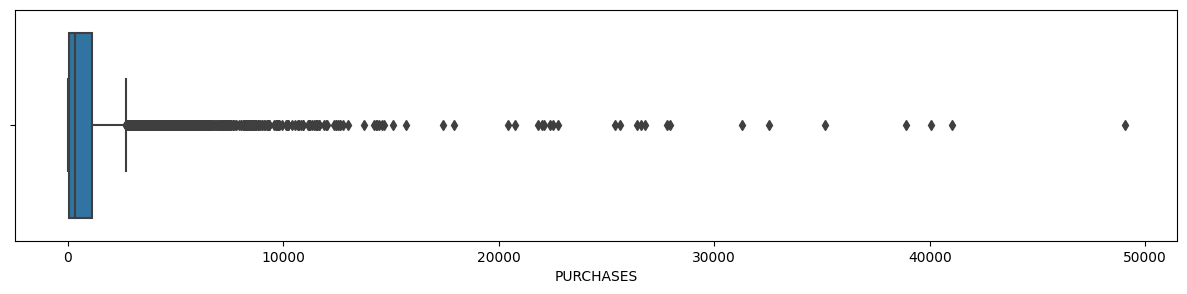

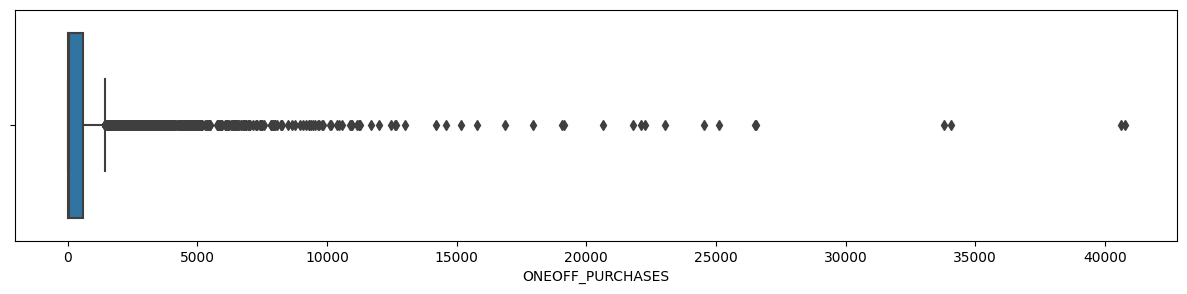

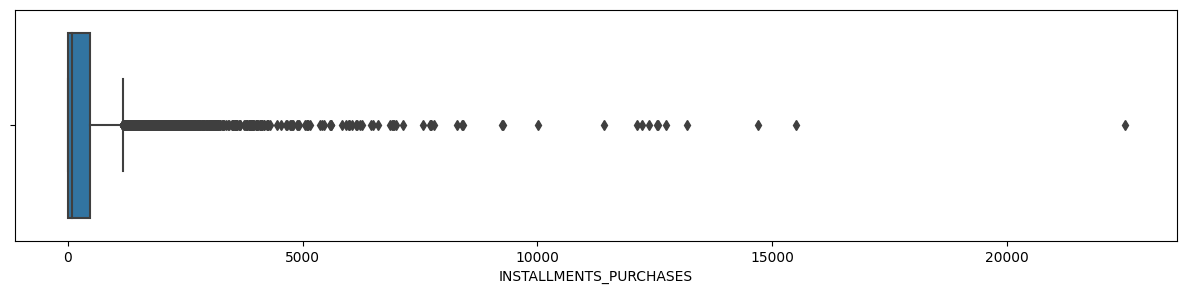

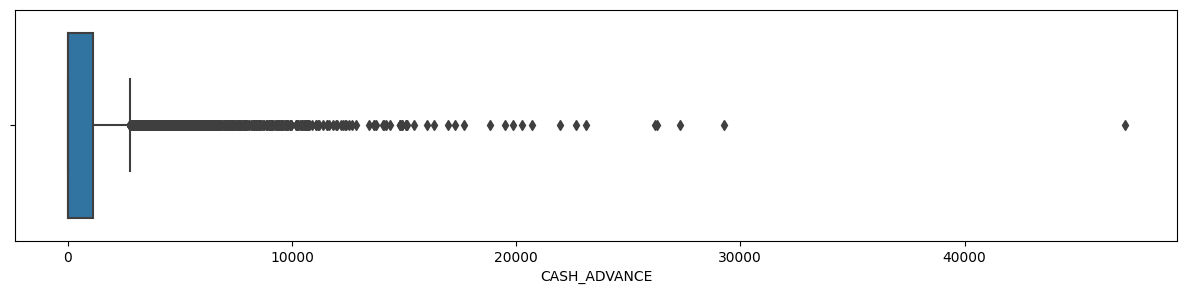

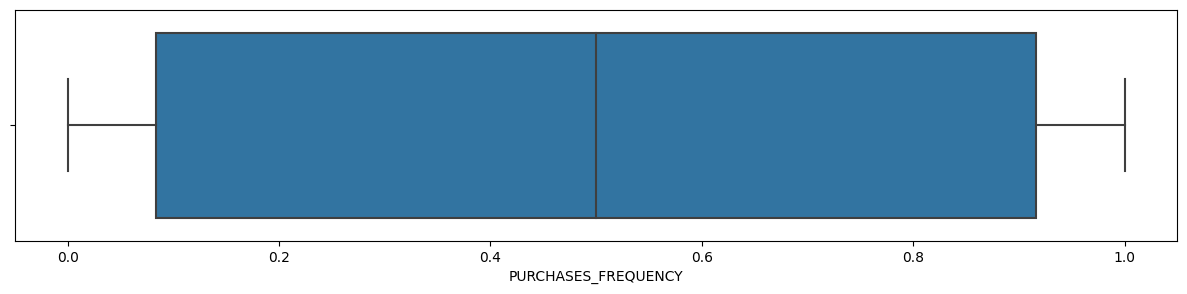

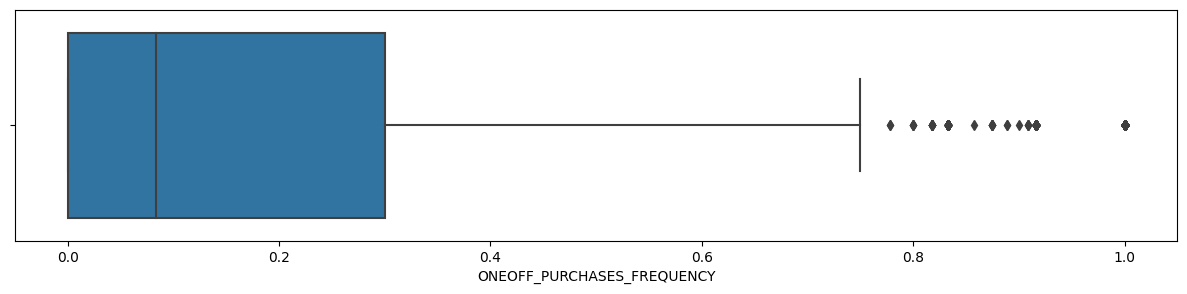

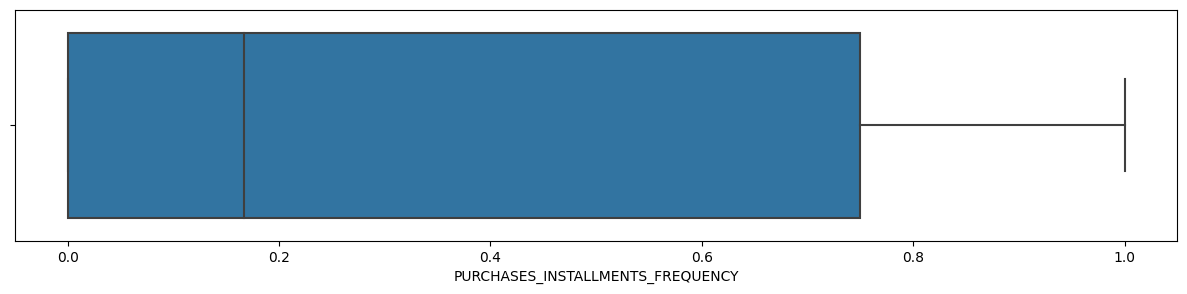

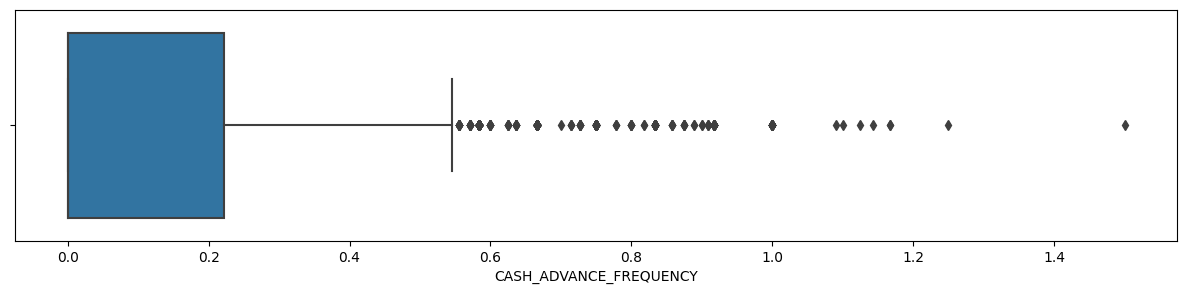

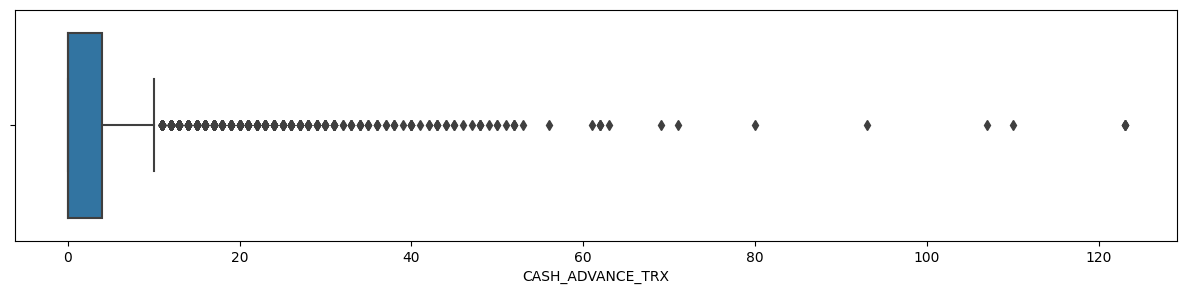

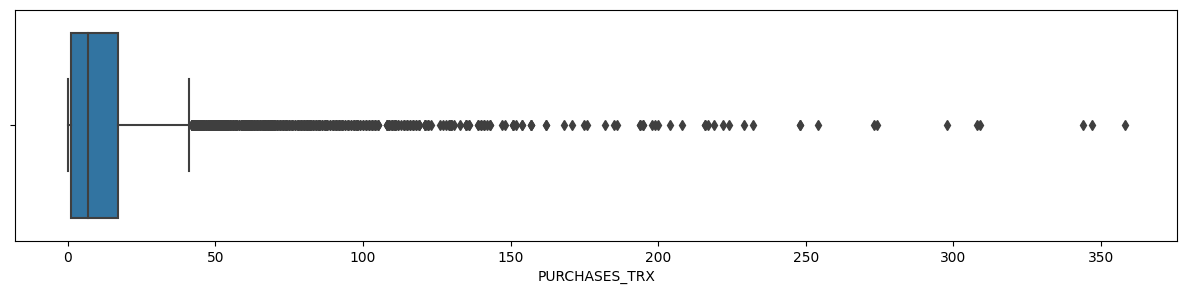

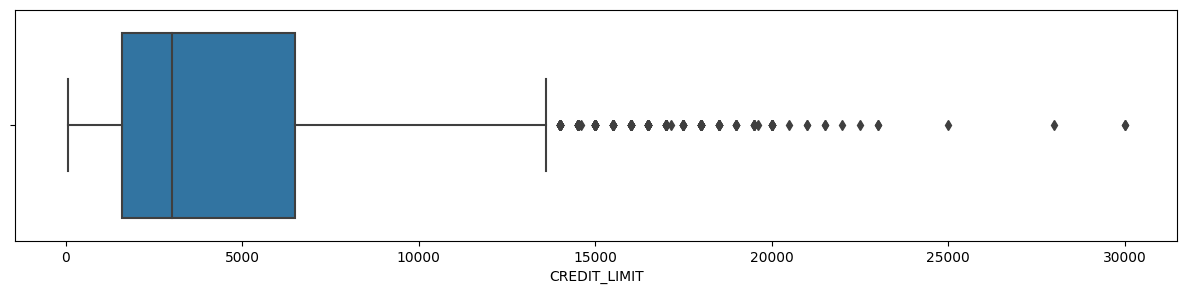

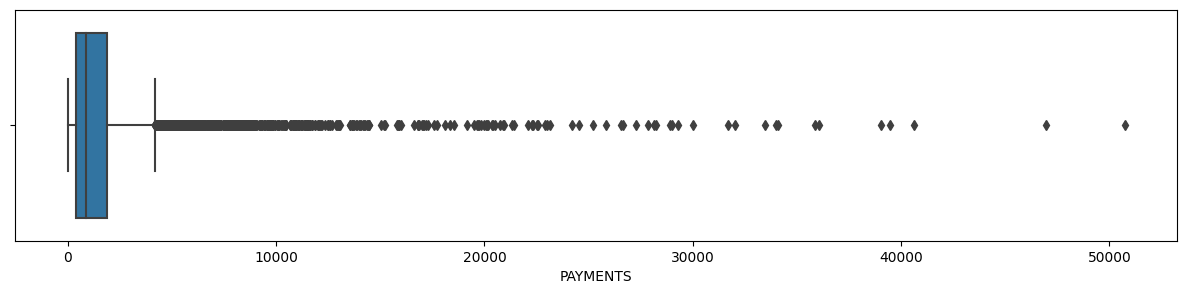

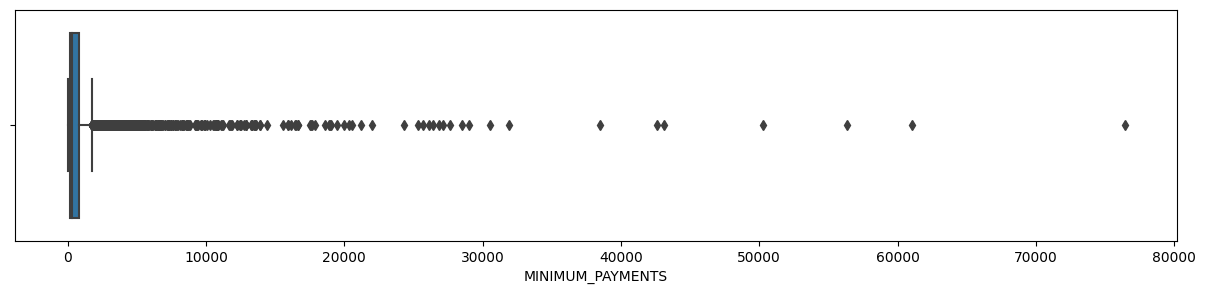

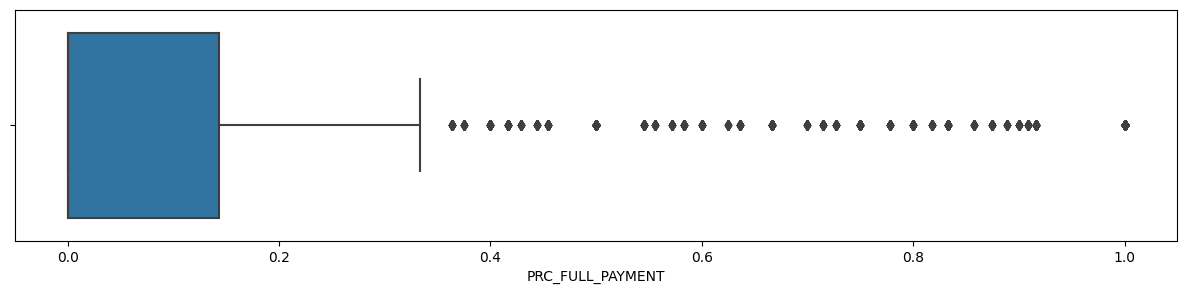

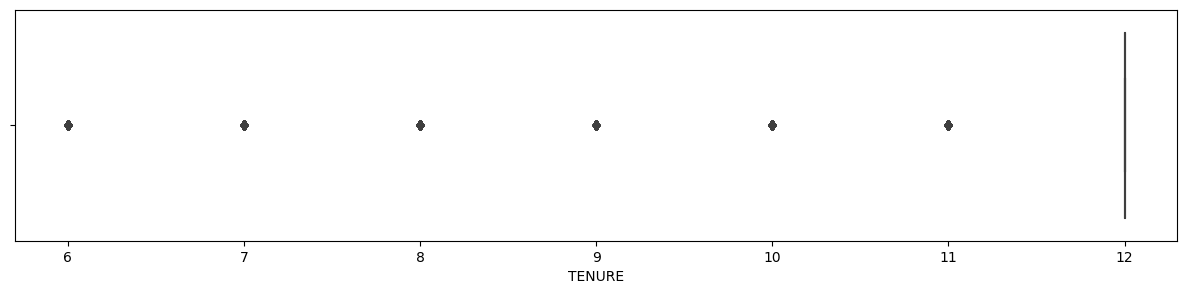

In [31]:
# for col in numeric_fetures:
#     try:
#         fig = plt.figure(figsize = (12, 3), dpi = 120)
#         sns.boxplot(x = data[col], data = data)
#     except:
#         continue
# plt.show()
for col in numeric_fetures:
    fig = plt.figure(figsize = (15, 3))
    sns.boxplot(x = data[col], data = data)
plt.show()

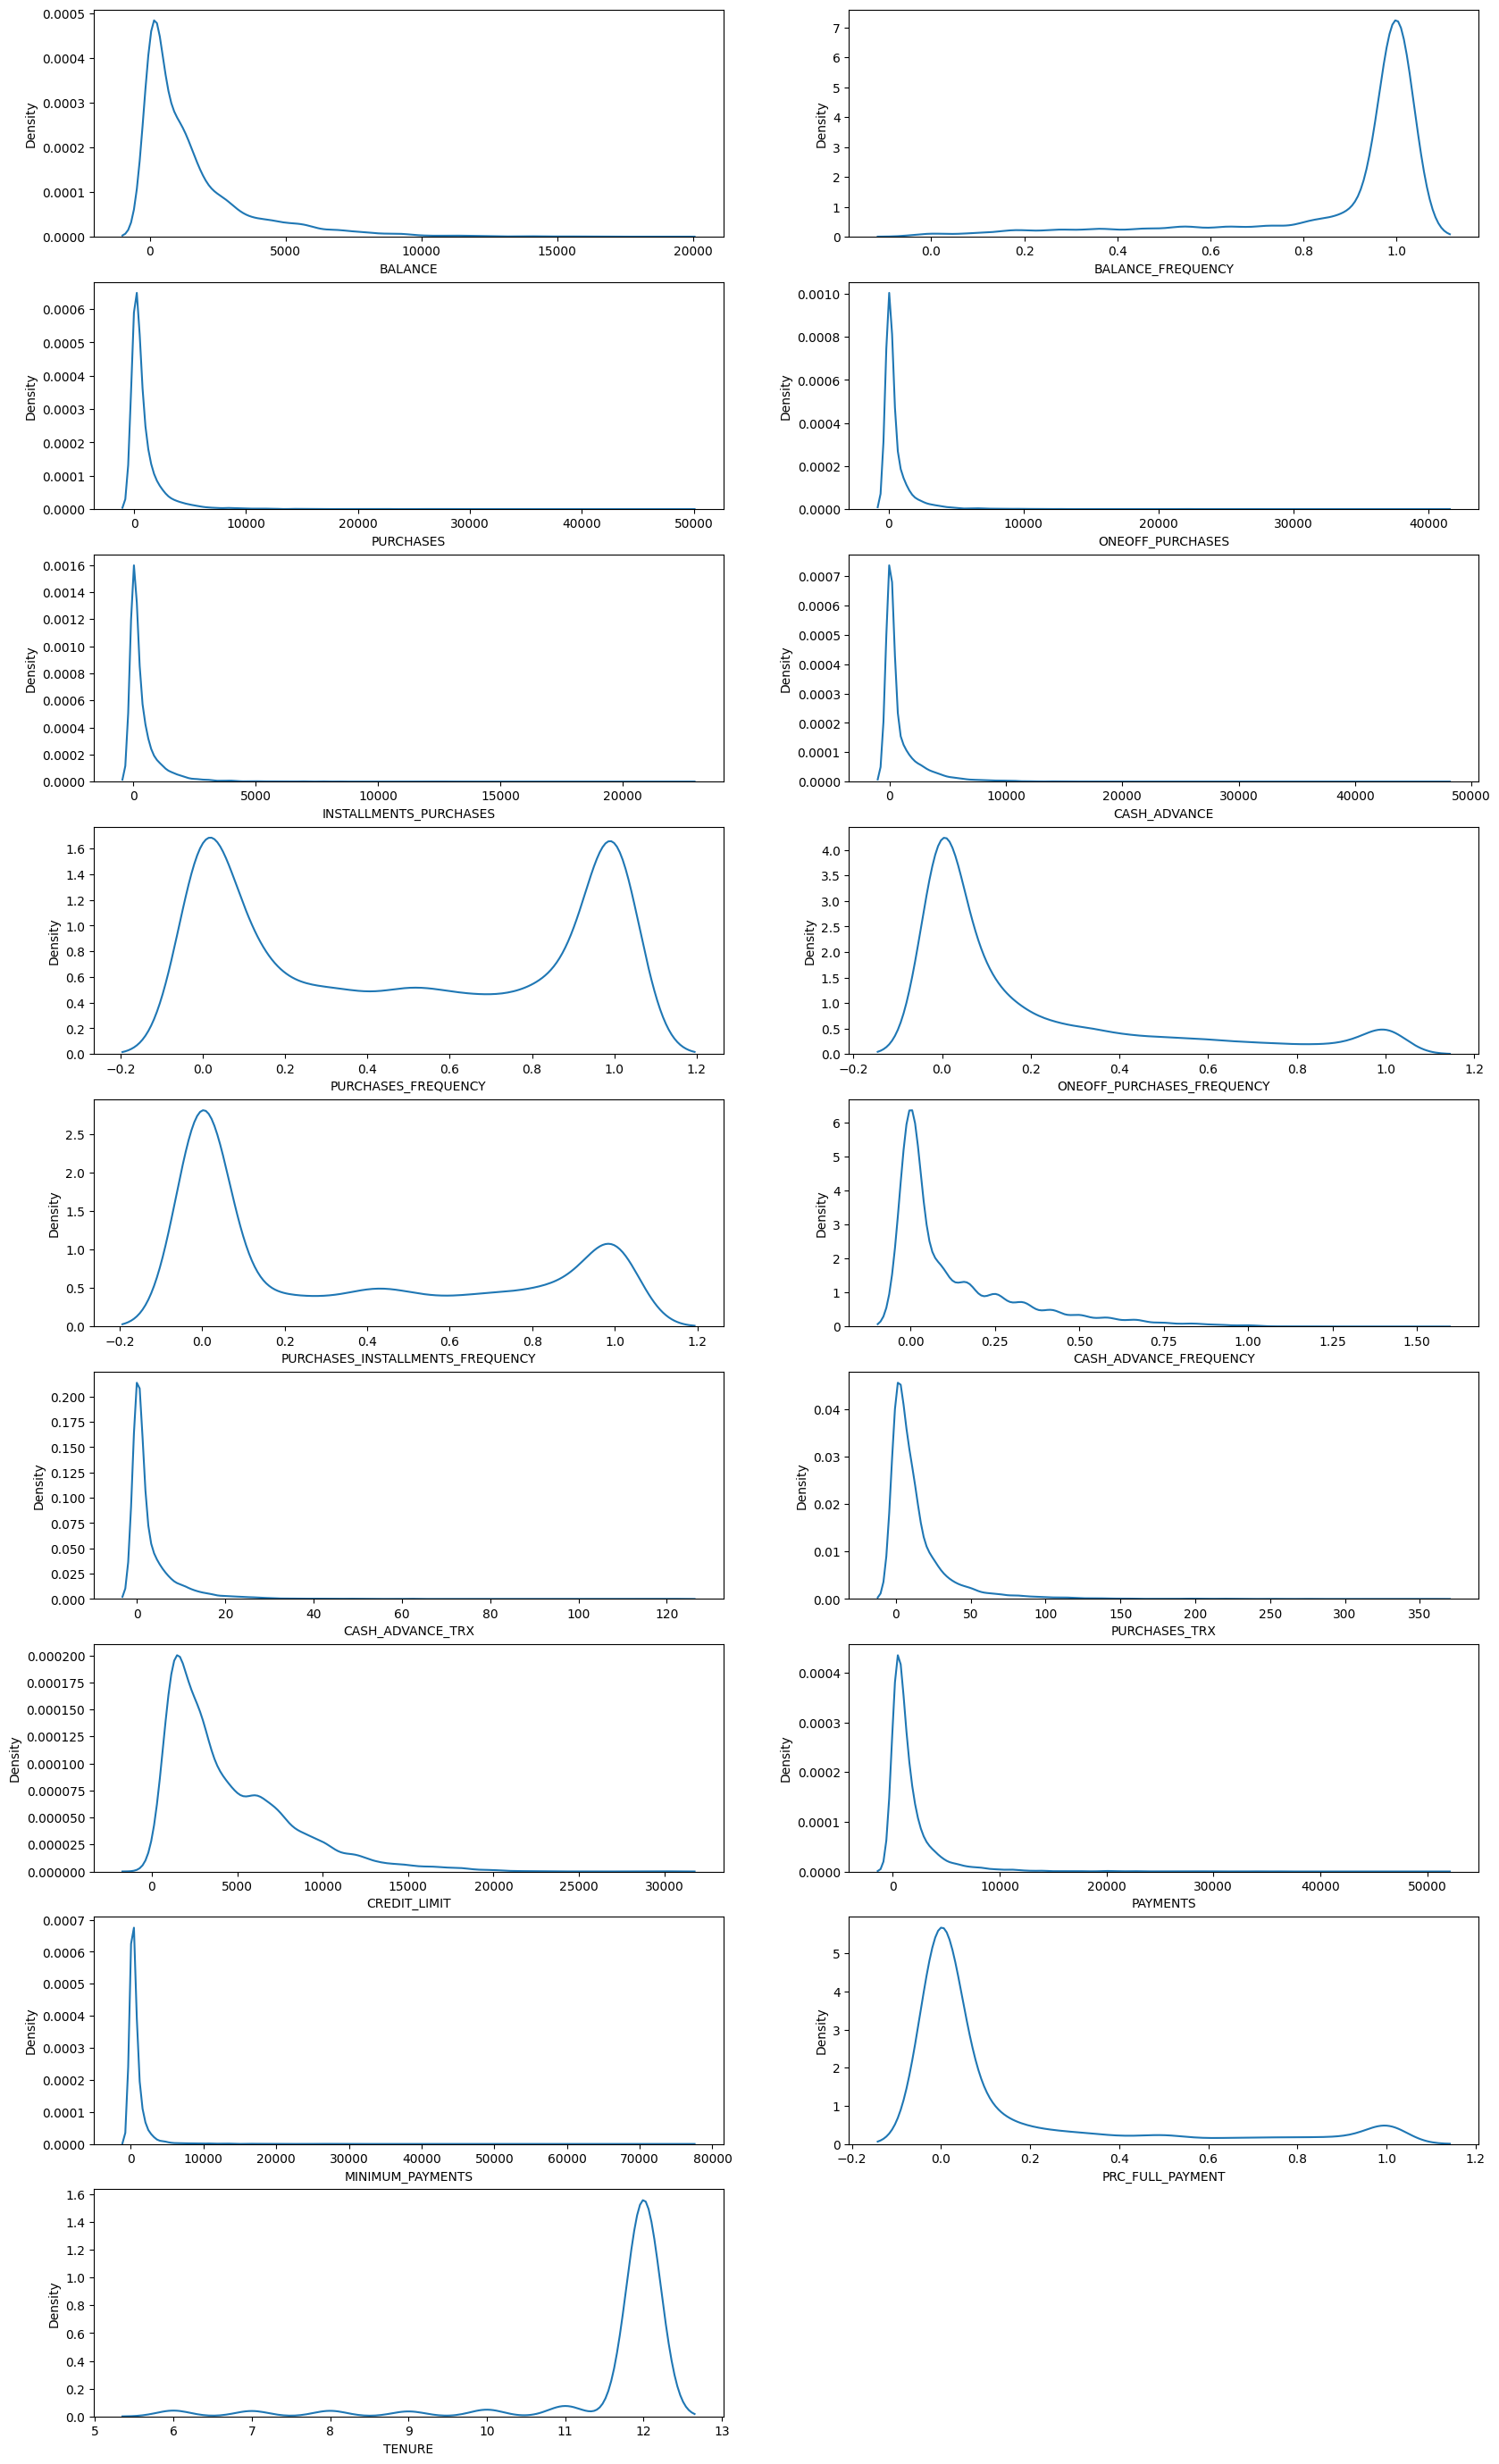

In [32]:
plt.figure(figsize=(20,35))
for i, col in enumerate(numeric_fetures):
    ax = plt.subplot(9, 2, i+1)
    sns.kdeplot(data[col], ax=ax)
    plt.xlabel(col)
        
plt.show()

<AxesSubplot: >

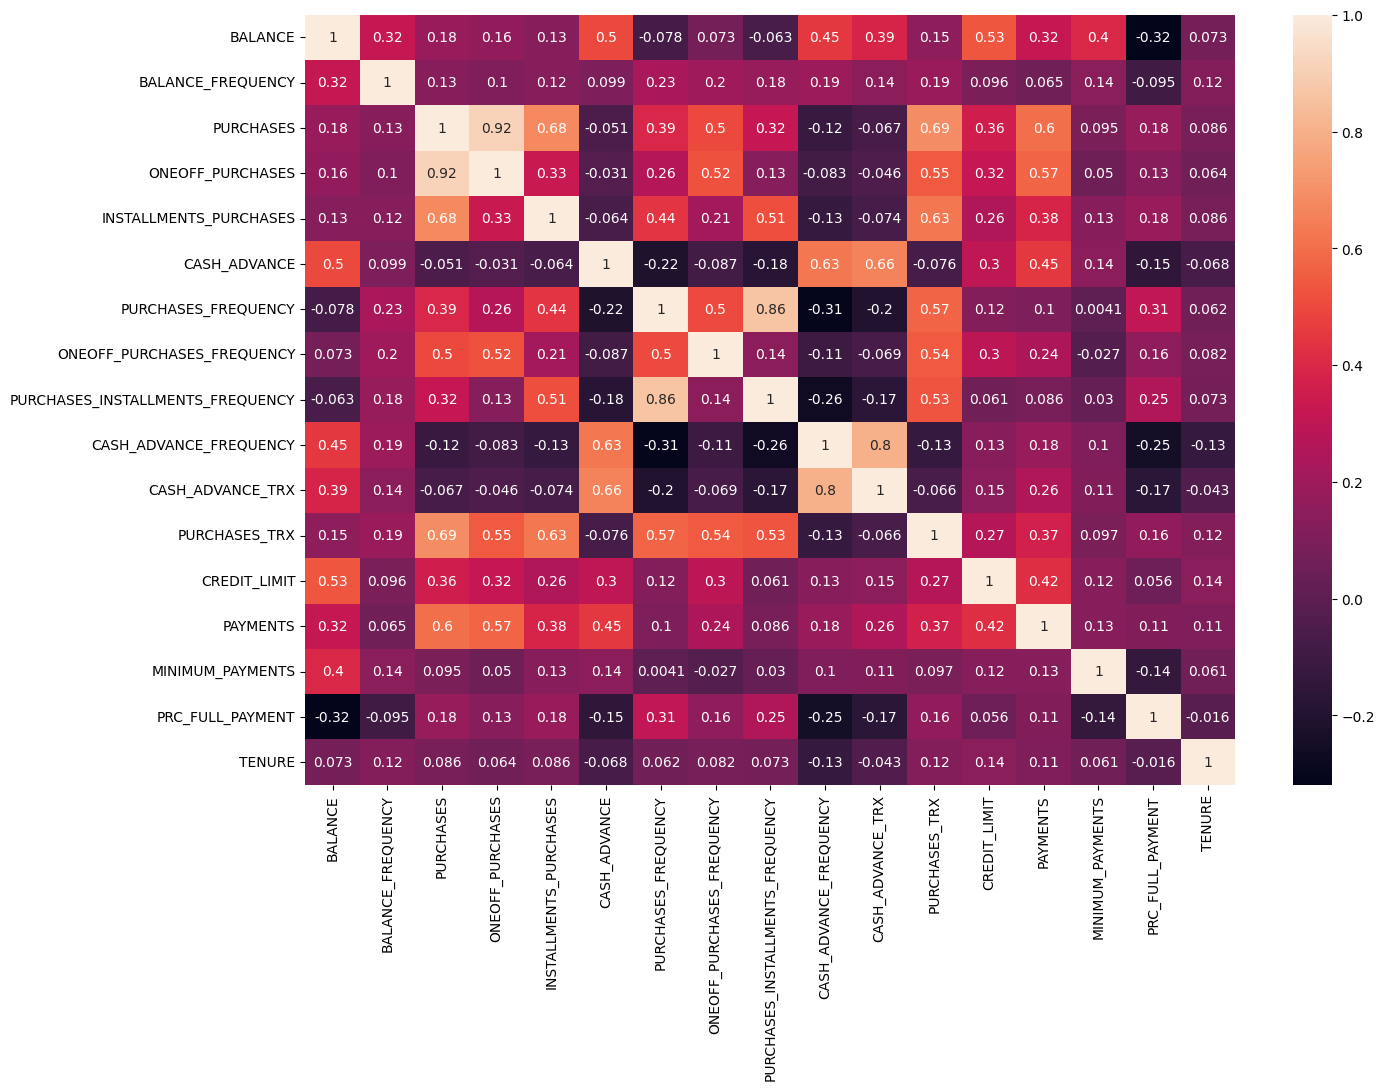

In [33]:
plt.figure(figsize=(15,10))
sns.heatmap(data.corr(), annot=True)

### Feature Scaling

##### As there is a lot of outliers, we'll use RobustScaler()

In [34]:
# Create a RobustScaler object
scaler = RobustScaler()

# Fit the RobustScaler to your dataframe
scaler.fit(data)

# Transform the dataframe using the fitted scaler
data_scaled = scaler.transform(data)

# Create a new dataframe with the scaled values
data_scaled = pd.DataFrame(data_scaled, columns=data.columns)

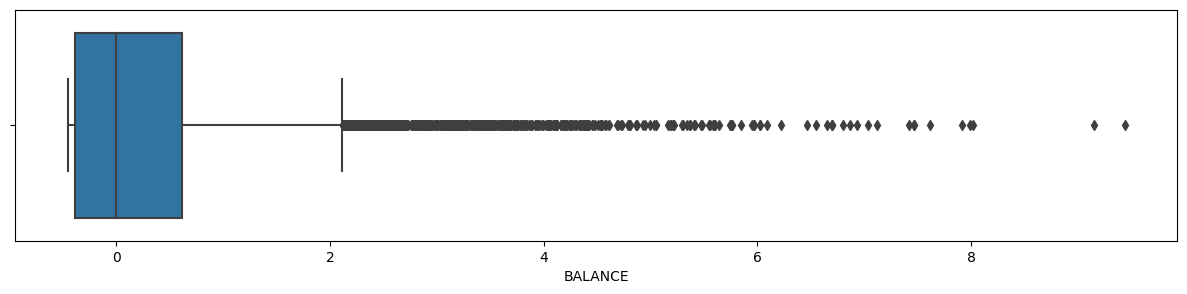

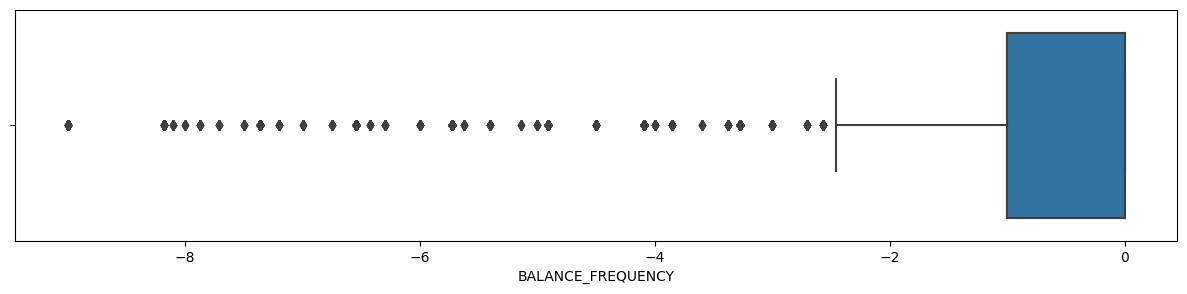

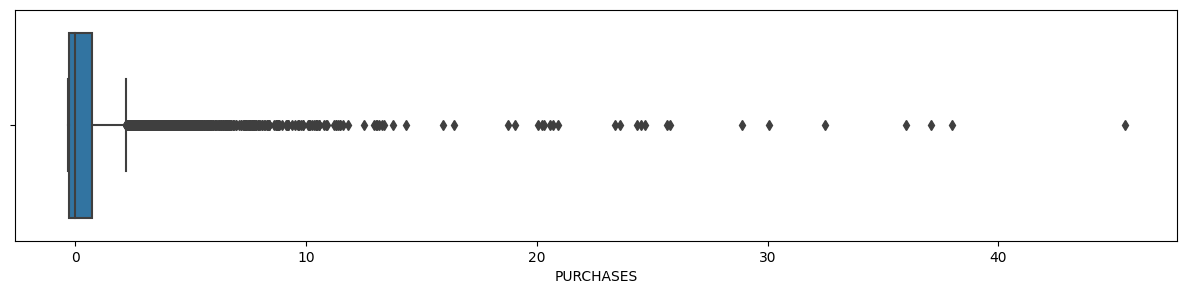

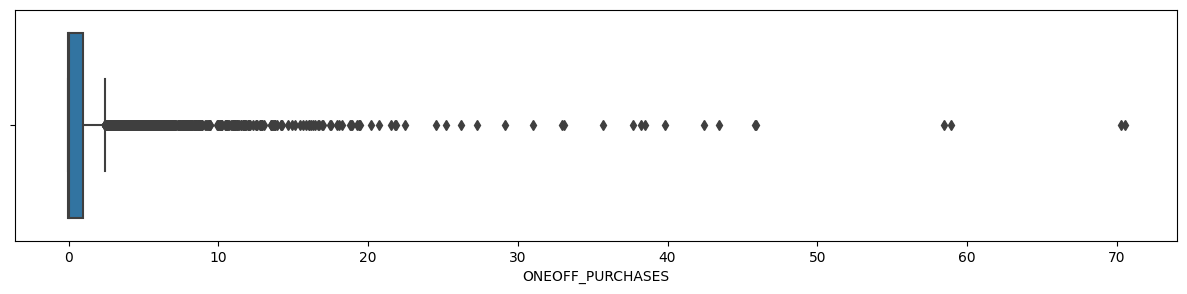

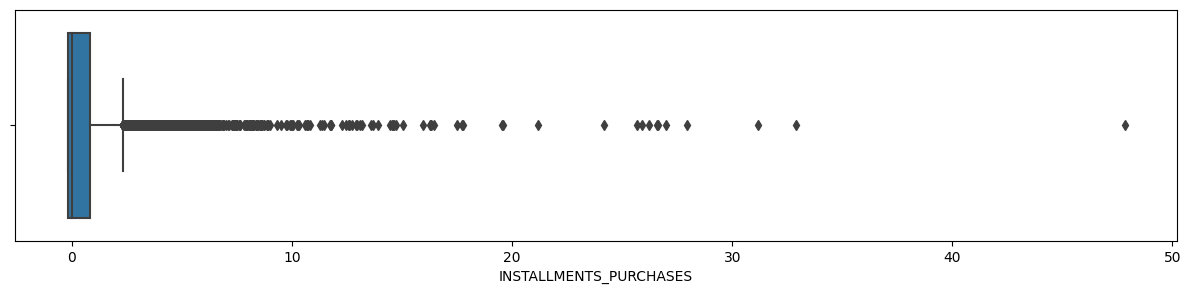

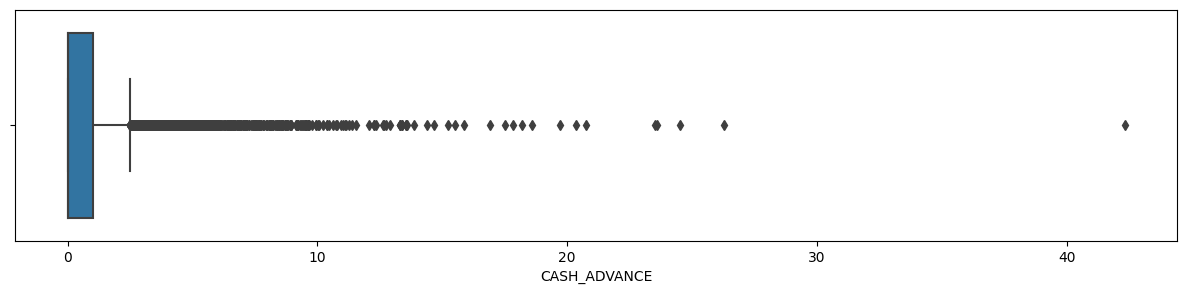

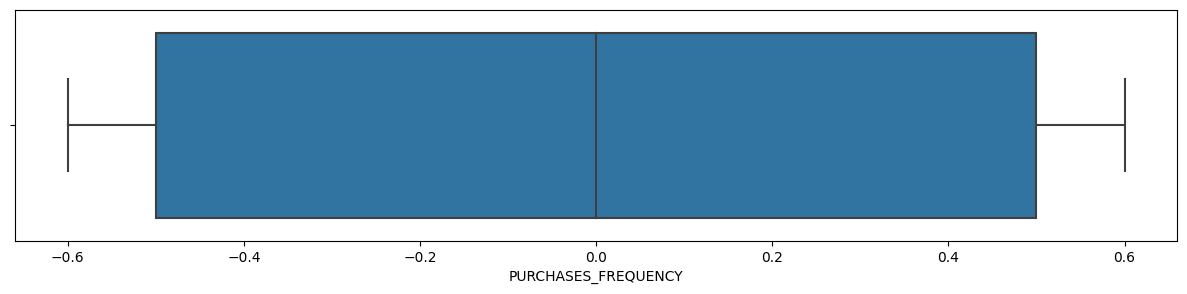

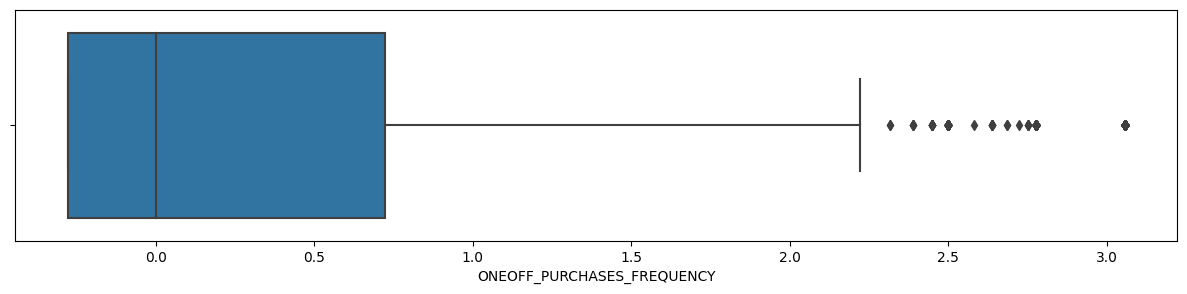

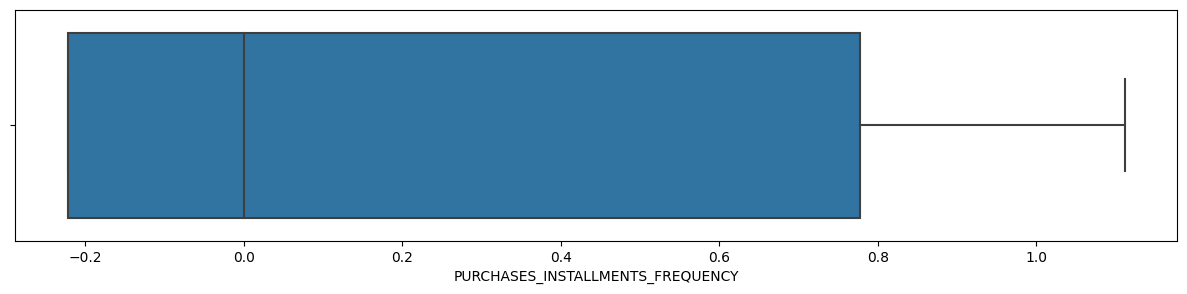

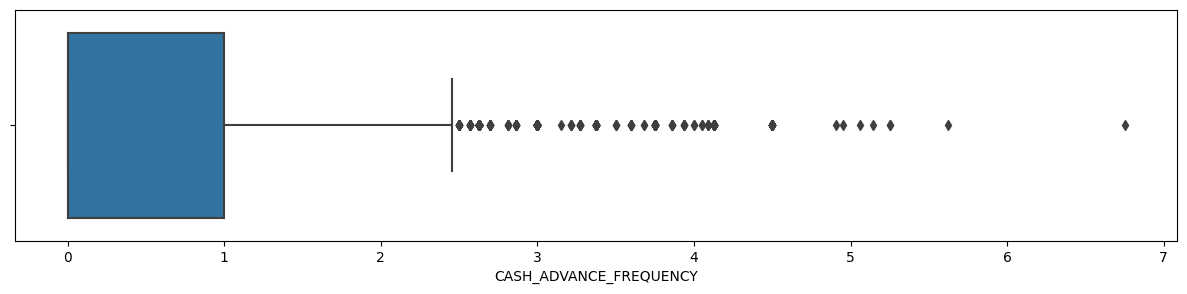

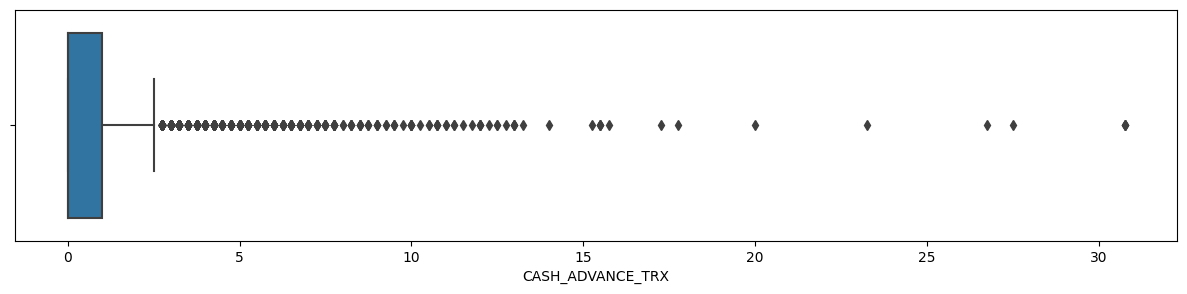

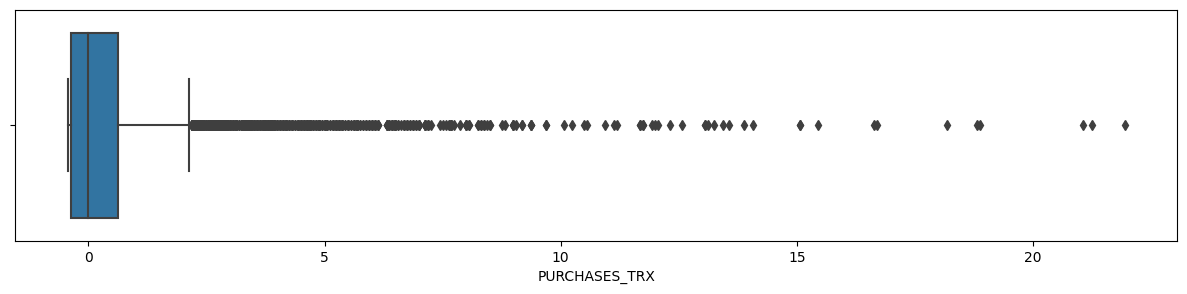

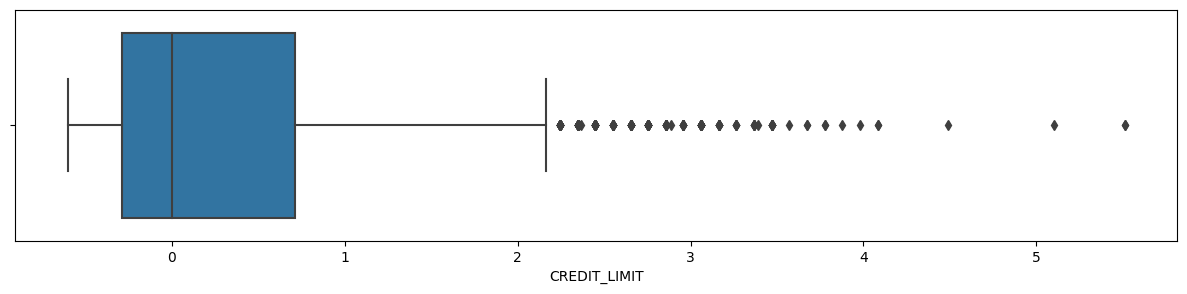

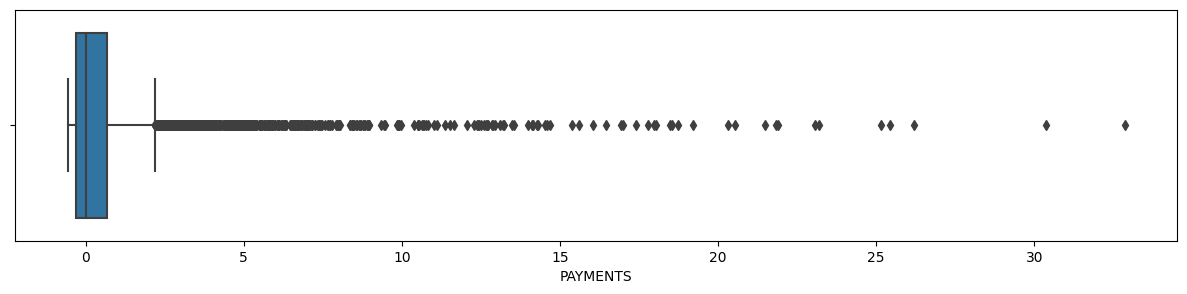

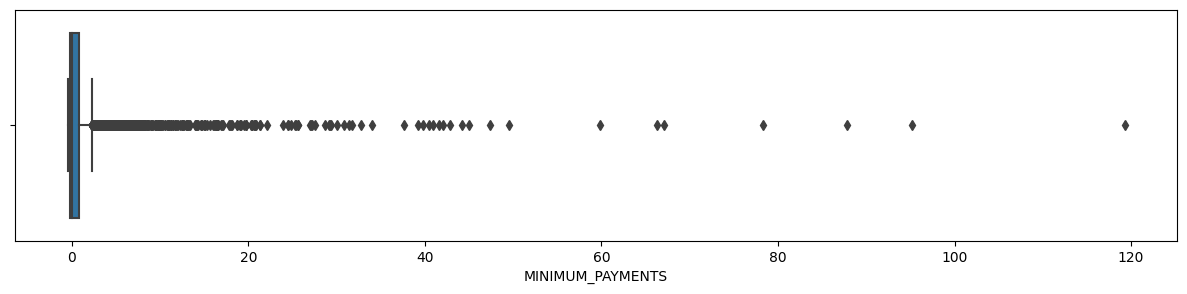

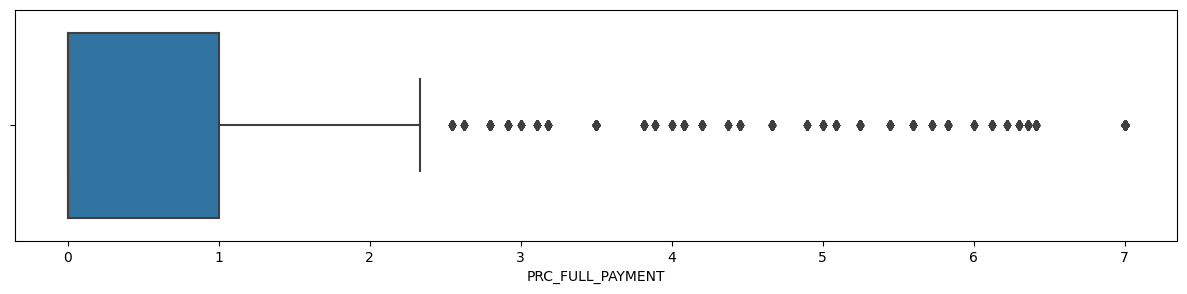

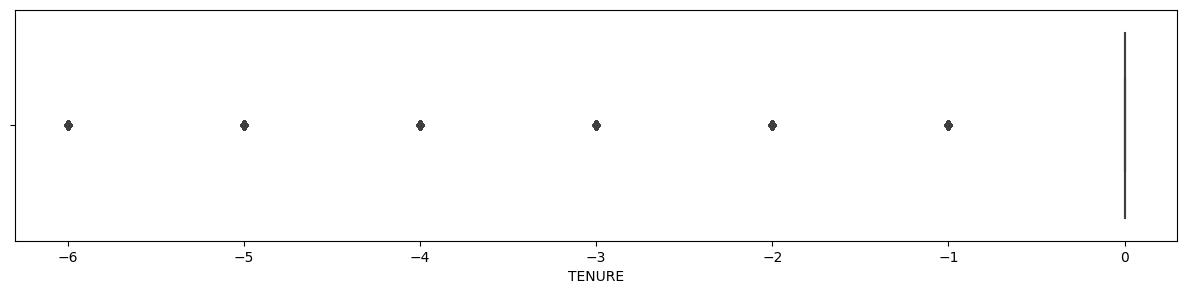

In [35]:
# for col in numeric_fetures:
#     try:
#         fig = plt.figure(figsize = (12, 3), dpi = 120)
#         sns.boxplot(x = data[col], data = data)
#     except:
#         continue
# plt.show()
for col in numeric_fetures:
    fig = plt.figure(figsize = (15, 3))
    sns.boxplot(x = data_scaled[col], data = data_scaled)
plt.show()

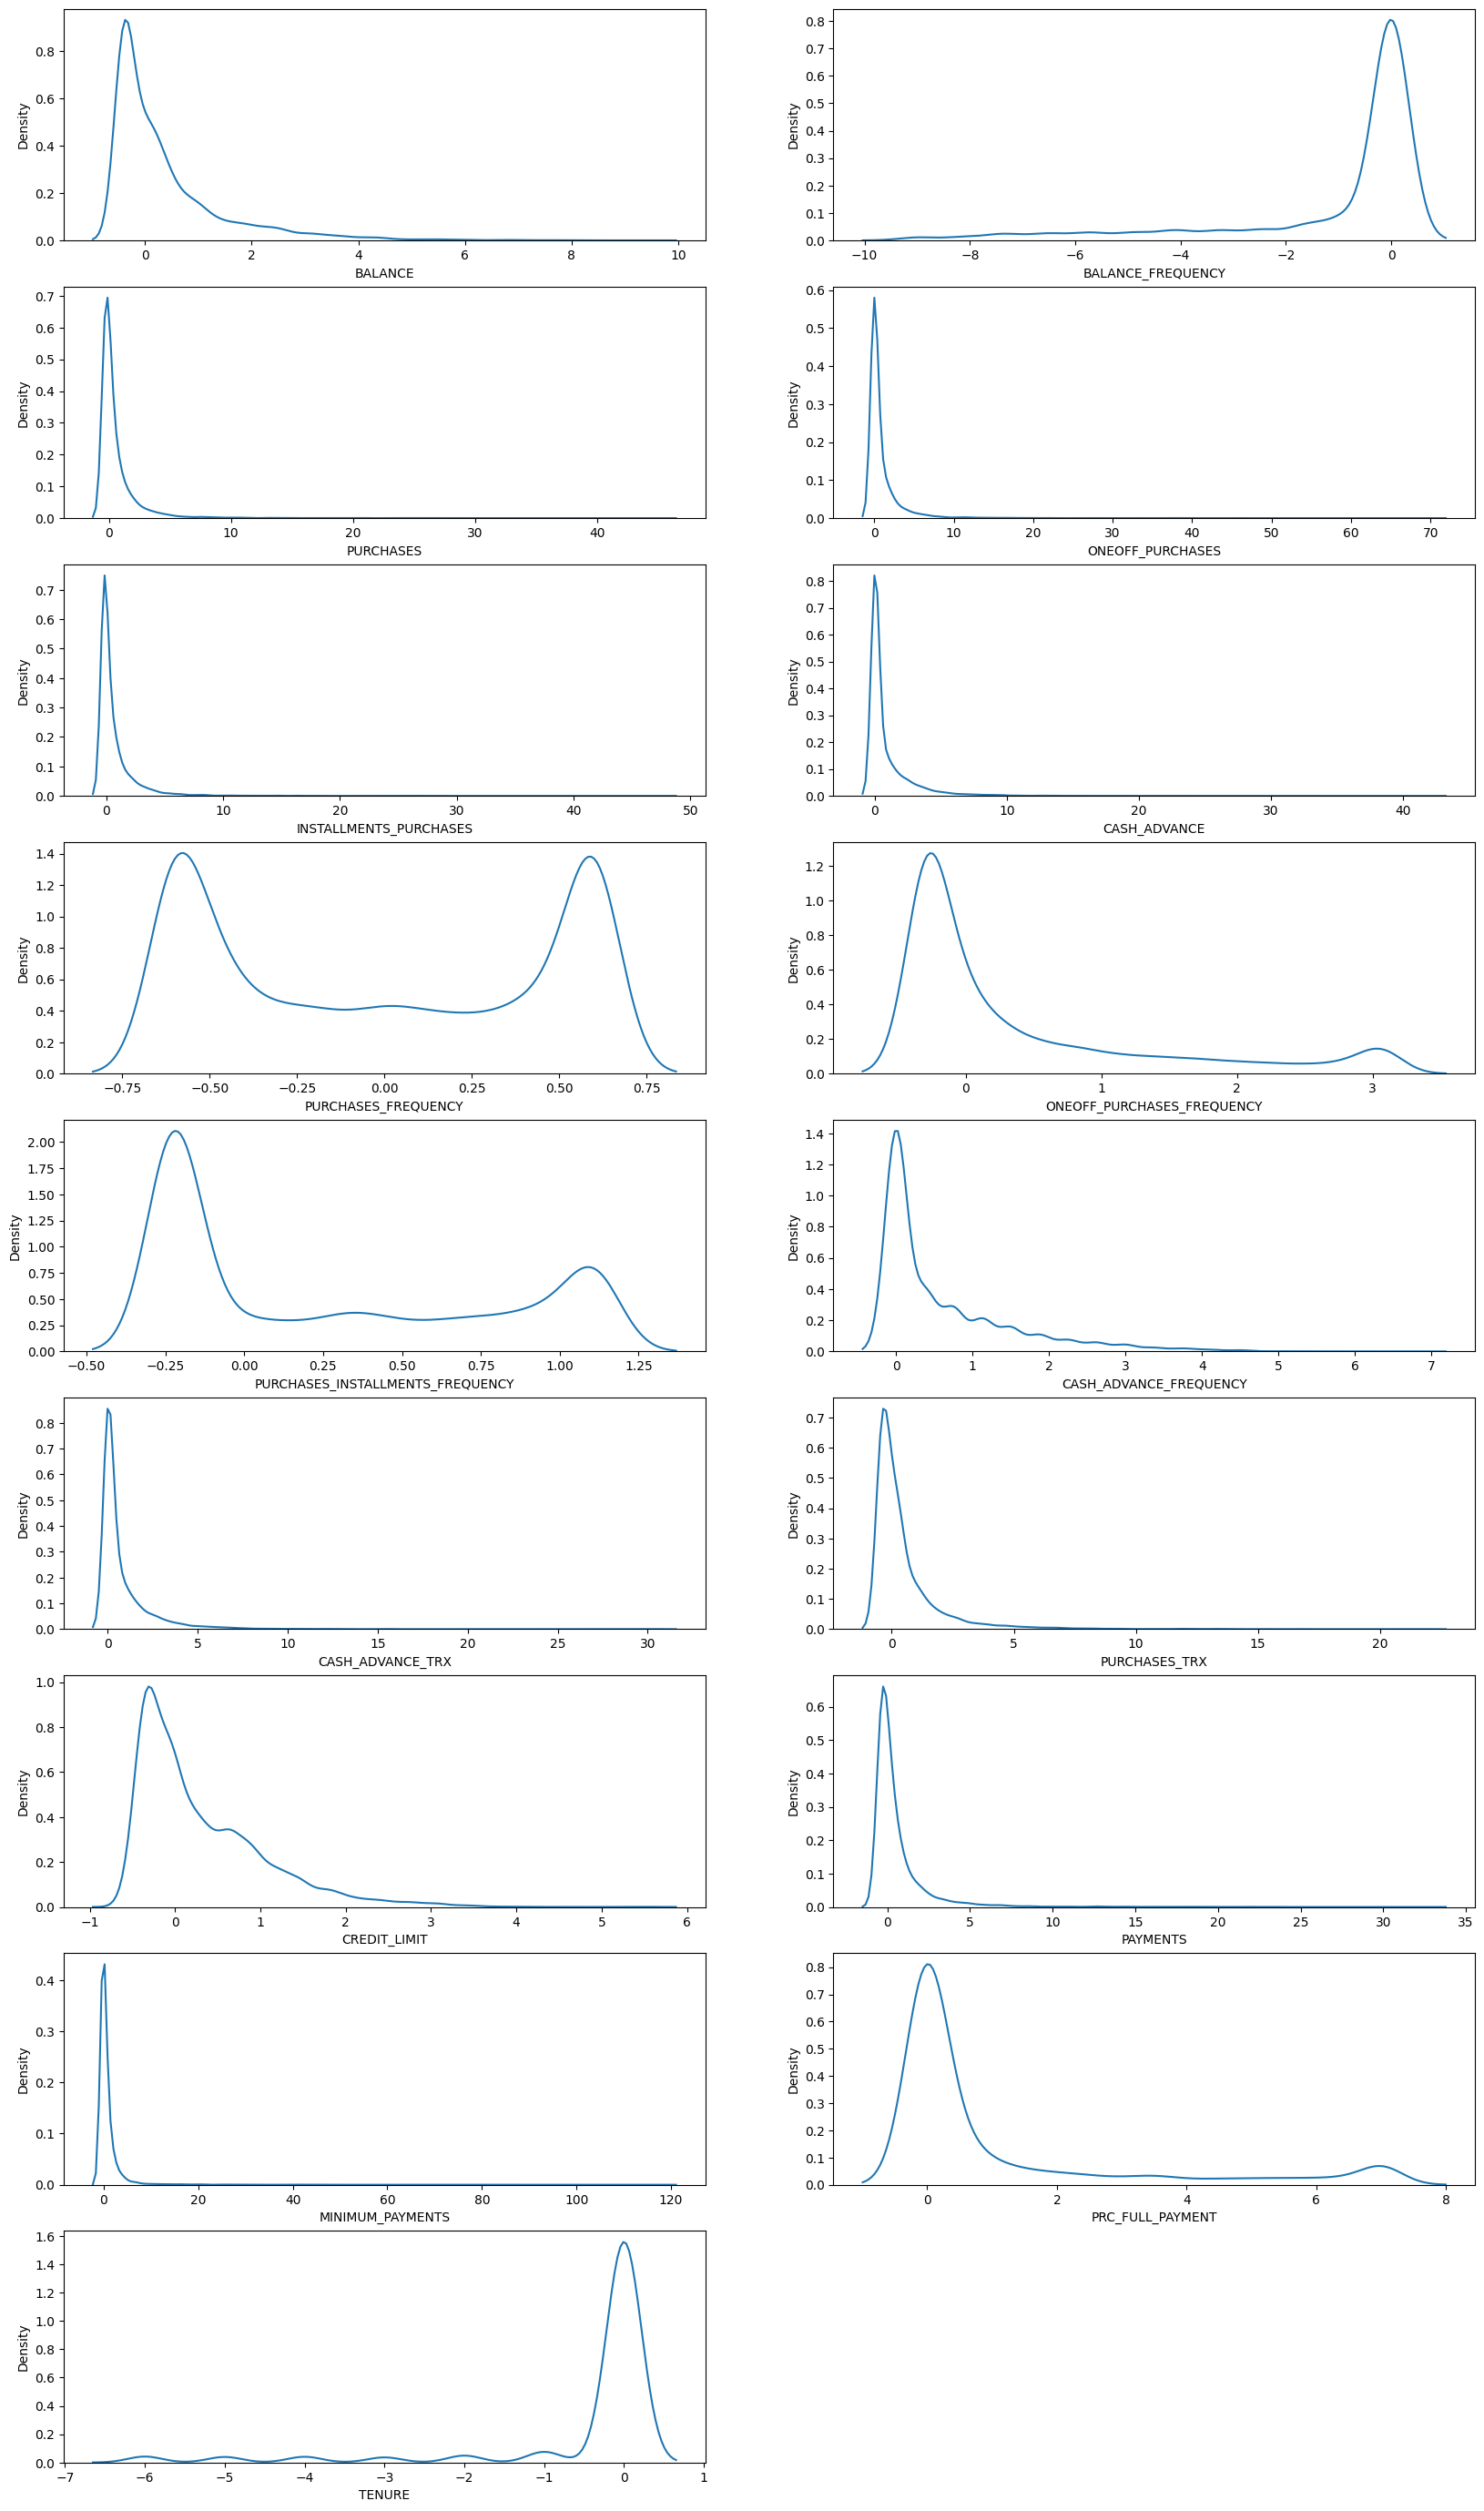

In [36]:
plt.figure(figsize=(20,35))
for i, col in enumerate(numeric_fetures):
    ax = plt.subplot(9, 2, i+1)
    sns.kdeplot(data_scaled[col], ax=ax)
    plt.xlabel(col)
        
plt.show()

In [37]:
numeric_fetures = data_scaled.select_dtypes(include=np.number).columns.tolist()
data_numeric = data_scaled[numeric_fetures]
data_numeric.shape

(8950, 17)

## Modeling

### DBSCAN

In [38]:
# define the model
model = DBSCAN(eps=0.30, min_samples=9)
# fit model and predict clusters
yhat = model.fit_predict(data_scaled)
# retrieve unique clusters
clusters = unique(yhat)
# create scatter plot for samples from each cluster
for cluster in clusters:
	# get row indexes for samples with this cluster
	row_ix = where(yhat == cluster)
	# create scatter of these samples
	plt.scatter(data_scaled[row_ix, 0], data_scaled[row_ix, 1])
# show the plot
pyplot.show()

InvalidIndexError: ((array([   0,    1,    2, ..., 8947, 8948, 8949], dtype=int64),), 0)

### Agglomerative Clustering

In [ ]:
# agglomerative clustering
from numpy import unique
from numpy import where
from sklearn.datasets import make_classification
from sklearn.cluster import AgglomerativeClustering
from matplotlib import pyplot

# define the model
model = AgglomerativeClustering(n_clusters=2)
# fit model and predict clusters
yhat = model.fit_predict(data_scaled)
# retrieve unique clusters
clusters = unique(yhat)
# create scatter plot for samples from each cluster
for cluster in clusters:
	# get row indexes for samples with this cluster
	row_ix = where(yhat == cluster)
	# create scatter of these samples
	pyplot.scatter(data_scaled[row_ix, 0], data_scaled[row_ix, 1])
# show the plot
pyplot.show()

InvalidIndexError: ((array([   6,    9,   12, ..., 8938, 8940, 8945], dtype=int64),), 0)

### K-means

In [ ]:
# k-means clustering
from sklearn.cluster import KMeans


# define the model
model = KMeans(n_clusters=2)
# fit the model
model.fit(data_scaled)
# assign a cluster to each example
yhat = model.predict(data_scaled)
# retrieve unique clusters
clusters = unique(yhat)
# create scatter plot for samples from each cluster
for cluster in clusters:
	# get row indexes for samples with this cluster
	row_ix = where(yhat == cluster)
	# create scatter of these samples
	pyplot.scatter(data_scaled[row_ix, 0], data_scaled[row_ix, 1])
# show the plot
pyplot.show()

d:\shAI l2\Project1 - Credit Card\credit-card-customer-segmentation\venv_DL_credit_card\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


InvalidIndexError: ((array([   0,    1,    2, ..., 8942, 8944, 8946], dtype=int64),), 0)

### Spectral Clustering

In [ ]:
X

array([[ 1.22515974, -0.95173116],
       [ 1.01630365, -1.72517506],
       [ 0.33534004, -1.7248955 ],
       ...,
       [ 1.54270795, -0.05566478],
       [ 0.81664566, -1.2509187 ],
       [ 1.13782254, -1.26151957]])

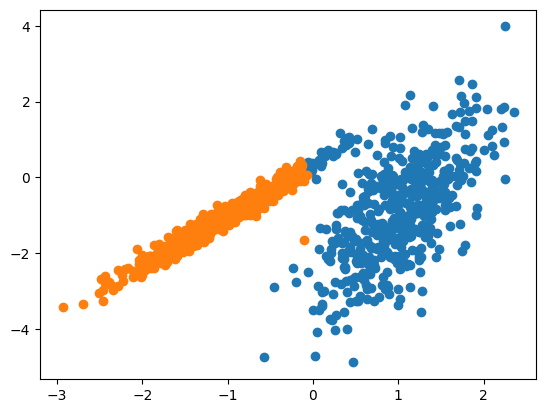

In [ ]:
# spectral clustering
from sklearn.cluster import SpectralClustering
from matplotlib import pyplot


# define the model
model = SpectralClustering(n_clusters=2)
# fit model and predict clusters
yhat = model.fit_predict(X)
# retrieve unique clusters
clusters = unique(yhat)
# create scatter plot for samples from each cluster
for cluster in clusters:
	# get row indexes for samples with this cluster
	row_ix = where(yhat == cluster)
	# create scatter of these samples
	pyplot.scatter(X[row_ix, 0], X[row_ix, 1])
# show the plot
pyplot.show()

In [39]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans,MiniBatchKMeans, MeanShift, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, QuantileTransformer
from sklearn.decomposition import PCA, KernelPCA
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm
from sklearn.impute import KNNImputer
import matplotlib.ticker as ticker
import warnings 
from sklearn.manifold import TSNE
warnings.filterwarnings('ignore')

#### PCA vs Kernel PCA

In [40]:
pca = PCA()
pca.fit(data_scaled)

PCA()

Text(0, 0.5, 'cumulative explained variance')

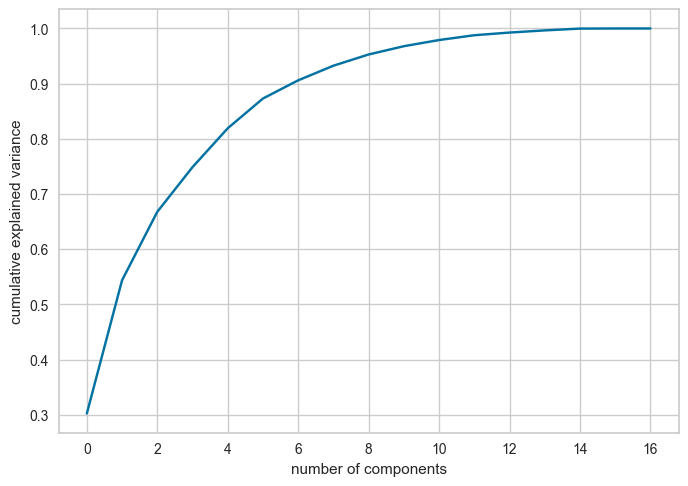

In [41]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')

In [42]:
np.cumsum(pca.explained_variance_ratio_)

array([0.30233463, 0.54371234, 0.66779557, 0.74876598, 0.81914676,
       0.87310142, 0.90605378, 0.93252962, 0.95288192, 0.96787151,
       0.97906556, 0.98775624, 0.99259667, 0.99653027, 0.9997748 ,
       0.99999901, 1.        ])

In [43]:
n_components=2
pca_final = PCA(n_components=n_components)
pca_final.fit(data_scaled)
pca_ccData = pca_final.fit_transform(data_scaled)

Text(0, 0.5, 'cumulative explained variance')

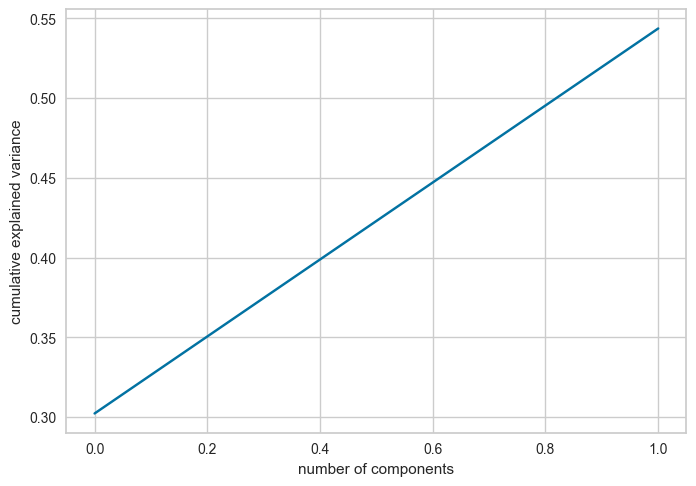

In [44]:
plt.plot(np.cumsum(pca_final.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')

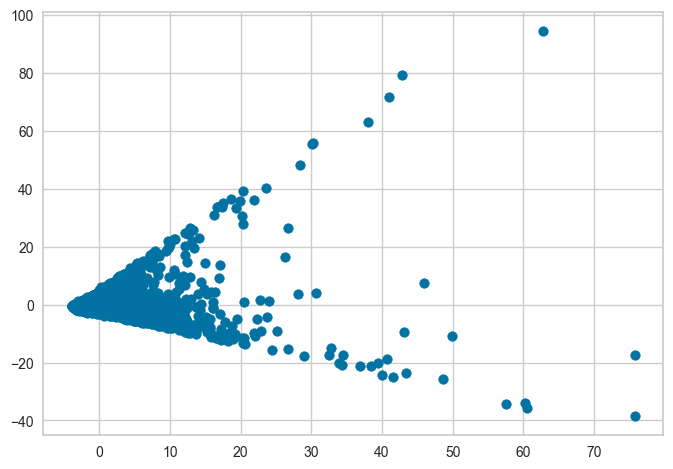

In [45]:
plt.scatter(pca_ccData[:,0], pca_ccData[:,1])

In [46]:
for i in np.arange(n_components):
    index =  np.argmax(np.absolute(pca_final.get_covariance()[i]))
    max_cov = pca_final.get_covariance()[i][index]
    column = data.columns[index]
    print("Principal Component", i+1, "maximum covariance :", "{:.2f}".format(max_cov), "from column", column)

Principal Component 1 maximum covariance : 2.04 from column BALANCE
Principal Component 2 maximum covariance : 2.05 from column BALANCE_FREQUENCY


In [47]:
for i in np.arange(n_components):
    index =  np.argmax(np.absolute(pca_final.get_covariance()[i]))
    max_cov = pca_final.get_covariance()[i][index]
    column = data.columns[index]
    print("Principal Component", i+1, "maximum covariance :", "{:.2f}".format(max_cov), "from column", column)

Principal Component 1 maximum covariance : 2.04 from column BALANCE
Principal Component 2 maximum covariance : 2.05 from column BALANCE_FREQUENCY


In [48]:
PCA_data = data_scaled.copy()

In [49]:
X_Pca = PCA(n_components=2).fit_transform(PCA_data)
X_KPca = KernelPCA(n_components=2, kernel='rbf').fit_transform(PCA_data)

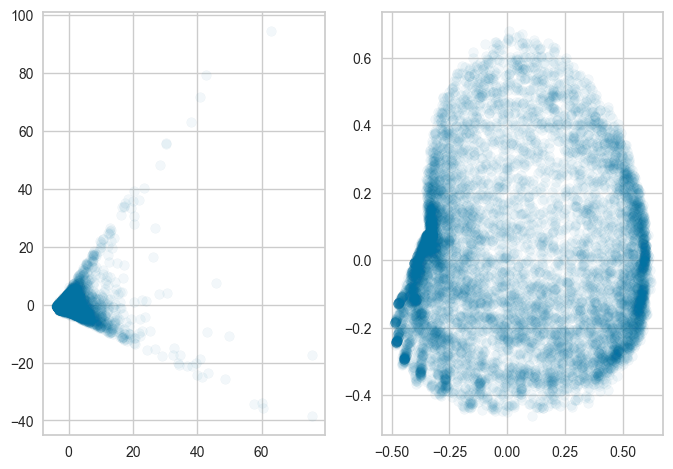

In [50]:
plt.subplot(1,2,1)
plt.scatter(X_Pca[:,0], X_Pca[:,1], alpha=.05)

plt.subplot(1,2,2)
plt.scatter(X_KPca[:,0], X_KPca[:,1], alpha=.05)

In [51]:
X_pca = PCA(n_components=2).fit_transform(PCA_data)
X_pca.shape

(8950, 2)

In [52]:
Kpca = KernelPCA(n_components=4,kernel='rbf', gamma=0.03)
X_reduced = Kpca.fit_transform(PCA_data)

In [53]:
X_reduced.shape

(8950, 4)

In [54]:
Pca_data = pd.DataFrame(X_reduced, columns= [f"PCA{i}" for i in range(X_reduced.shape[1])])
Pca_data.head()

,PCA0,PCA1,PCA2,PCA3
0,-0.347104,0.352597,-0.097397,0.015375
1,0.196916,-0.346857,-0.265748,0.147048
2,-0.194413,-0.068749,0.201963,-0.316106
3,0.002959,0.277543,-0.131338,-0.232079
4,-0.482489,0.136489,-0.006413,0.046793


In [55]:
# pca.explained_variance_ratio_.sum()*100

# Modelling:-

#### Choose the best k value :- 
#### 1- using Kmeans:-

In [56]:
X = X_pca.copy()

In [57]:
inertia_scores = []
silhouette_scores = []
for i in range(2,10):
    Kmeans = KMeans(n_clusters=i, random_state=42)
    Kmeans.fit(X)
    inertia_scores.append(Kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, Kmeans.labels_))

In [58]:
silhouette_scores

[0.787730073396598,
 0.7335134199420499,
 0.6503409279517458,
 0.5774139724581151,
 0.5320848208133098,
 0.5186478369561587,
 0.43156889084106265,
 0.44622728548767626]

In [60]:
np.argmax(silhouette_scores) + 2

2

###### ElBowVizualizer:-

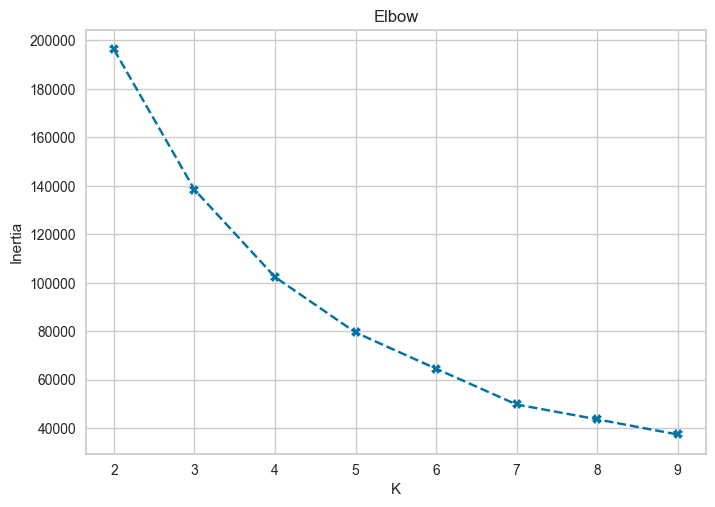

In [61]:
plt.plot(range(2,10), inertia_scores, "--X")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow")
plt.show()

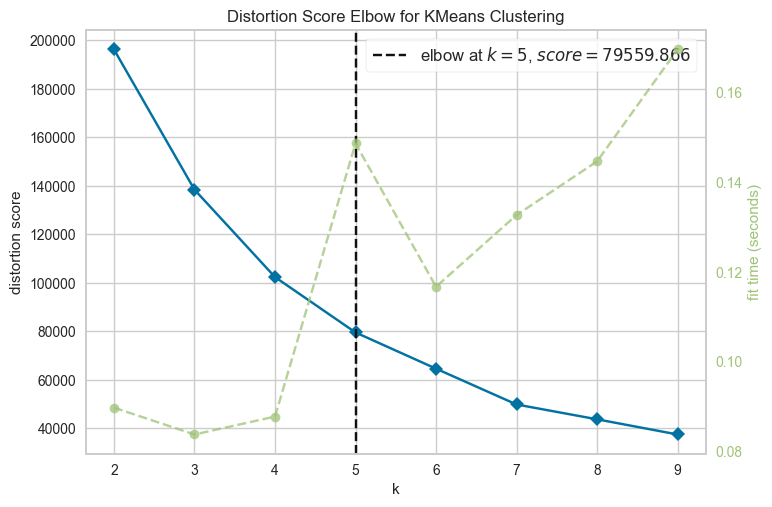

<AxesSubplot: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [62]:
visualizer = KElbowVisualizer(KMeans(random_state=42), k=(2,10))

visualizer.fit(X)        # Fit the data to the visualizer
visualizer.show()  

In [63]:
# visualizer = KElbowVisualizer(AgglomerativeClustering(), k=(2,10))

# visualizer.fit(X)        # Fit the data to the visualizer
# visualizer.show()  

In [64]:
X_TSNE = TSNE(n_components=2,
                   perplexity=3,
                   init='pca', 
                   method='barnes_hut', 
                   n_jobs=-1, 
                   random_state=42).fit_transform(X)

## Vizualization for each cluster

In [65]:
def silhouette_plot(model,range_n_clusters,X_clustering,X_TSNE,**kwargs):
    for n_clusters in range_n_clusters:
        # Create a subplot with 1 row and 2 columns
        fig, (ax1, ax2) = plt.subplots(1, 2)
        fig.set_size_inches(18, 7)

        # The 1st subplot is the silhouette plot
        # The silhouette coefficient can range from -1, 1 but in this example all
        # lie within [-0.1, 1]
        ax1.set_xlim([-0.1, 1])
        # The (n_clusters+1)*10 is for inserting blank space between silhouette
        # plots of individual clusters, to demarcate them clearly.
        ax1.set_ylim([0, len(X_clustering) + (n_clusters + 1) * 10])

        # Initialize the clusterer with n_clusters value and a random generator
        # seed of 10 for reproducibility.
        clusterer = model(n_clusters,**kwargs)
        cluster_labels = clusterer.fit_predict(X_clustering)

        # The silhouette_score gives the average value for all the samples.
        # This gives a perspective into the density and separation of the formed
        # clusters
        silhouette_avg = silhouette_score(X_clustering, cluster_labels)
        print(
            "For n_clusters =",
            n_clusters,
            "The average silhouette_score is :",
            silhouette_avg,
        )

        # Compute the silhouette scores for each sample
        sample_silhouette_values = silhouette_samples(X_clustering, cluster_labels)

        y_lower = 10
        for i in range(n_clusters):
            # Aggregate the silhouette scores for samples belonging to
            # cluster i, and sort them
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_clusters)
#             color  = cluster_colors
            ax1.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                ith_cluster_silhouette_values,
                facecolor=color,
                edgecolor=color,
                alpha=0.7,
            )

            # Label the silhouette plots with their cluster numbers at the middle
            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

            # Compute the new y_lower for next plot
            y_lower = y_upper + 10  # 10 for the 0 samples

        ax1.set_title("The silhouette plot for the various clusters.")
        ax1.set_xlabel("The silhouette coefficient values")
        ax1.set_ylabel("Cluster label")

        # The vertical line for average silhouette score of all the values
        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

        ax1.set_yticks([])  # Clear the yaxis labels / ticks
        ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

        # 2nd Plot showing the actual clusters formed
    #     colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)

        sns.scatterplot(
            x = X_TSNE[:, 0],
            y = X_TSNE[:, 1],
            hue=cluster_labels,
            palette=sns.color_palette("colorblind", len(set(cluster_labels))),
            alpha=0.3,
            legend="full",
            ax = ax2
        )
        ax2.set_title("The visualization of the clustered data.")
        ax2.set_xlabel("Feature space for the 1st feature")
        ax2.set_ylabel("Feature space for the 2nd feature")

        plt.suptitle(
            f"Silhouette analysis for {model.__name__} clustering on sample data with n_clusters = %d"
            % n_clusters,
            fontsize=14,
            fontweight="bold",
        )

    plt.show()



For n_clusters = 2 The average silhouette_score is : 0.787730073396598
For n_clusters = 3 The average silhouette_score is : 0.7335134199420499
For n_clusters = 4 The average silhouette_score is : 0.6509802932068195
For n_clusters = 5 The average silhouette_score is : 0.5771782707973078
For n_clusters = 6 The average silhouette_score is : 0.5058449987998886
For n_clusters = 7 The average silhouette_score is : 0.5207160940991655


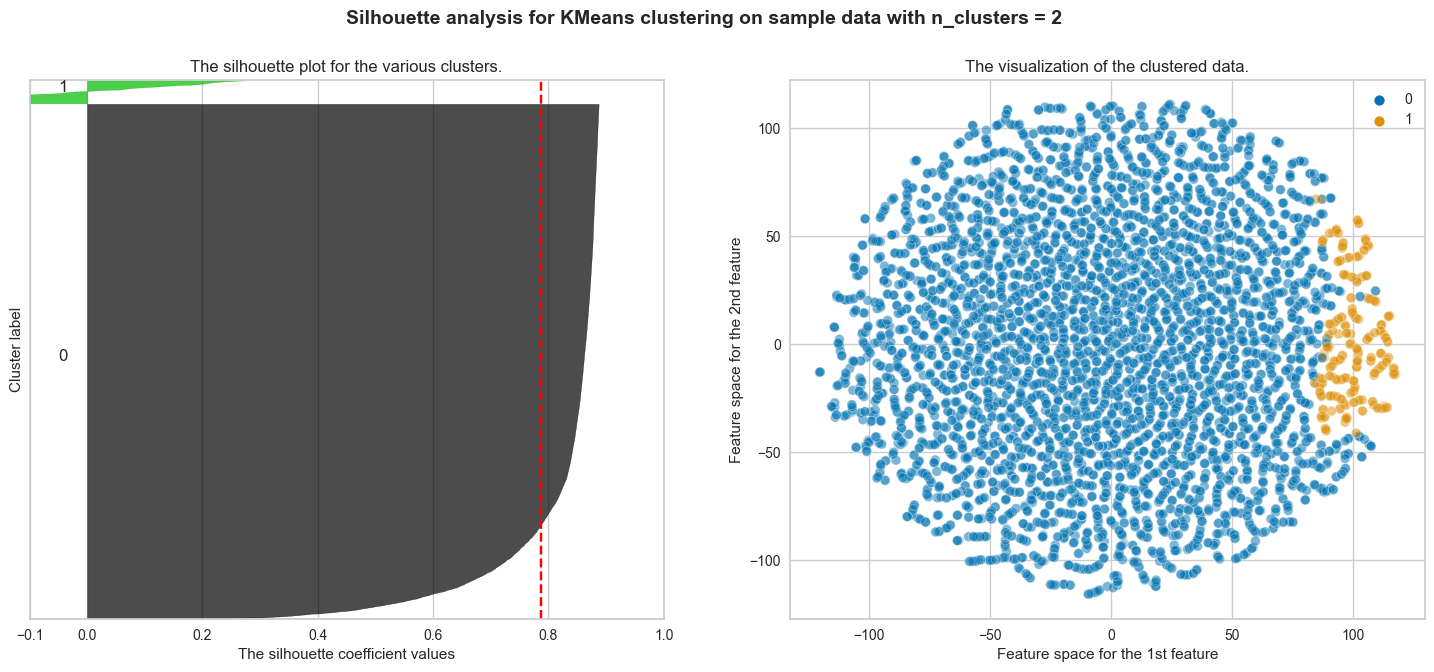

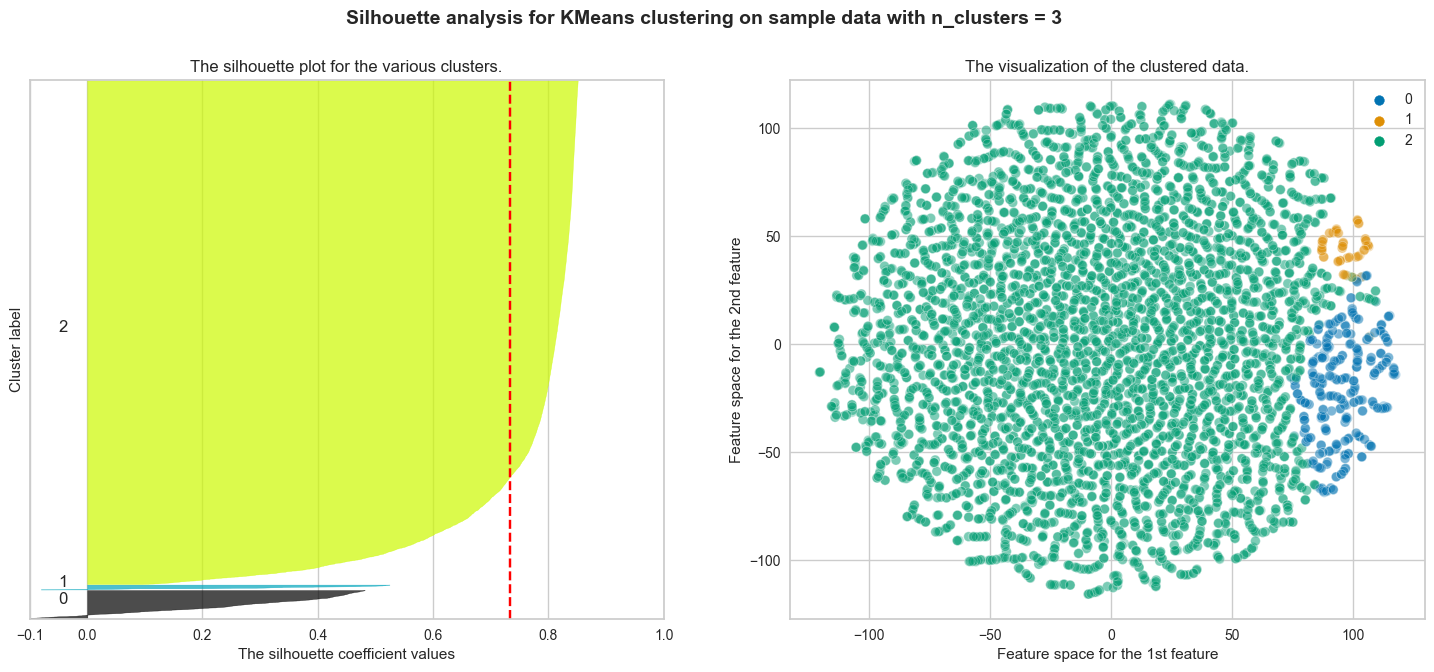

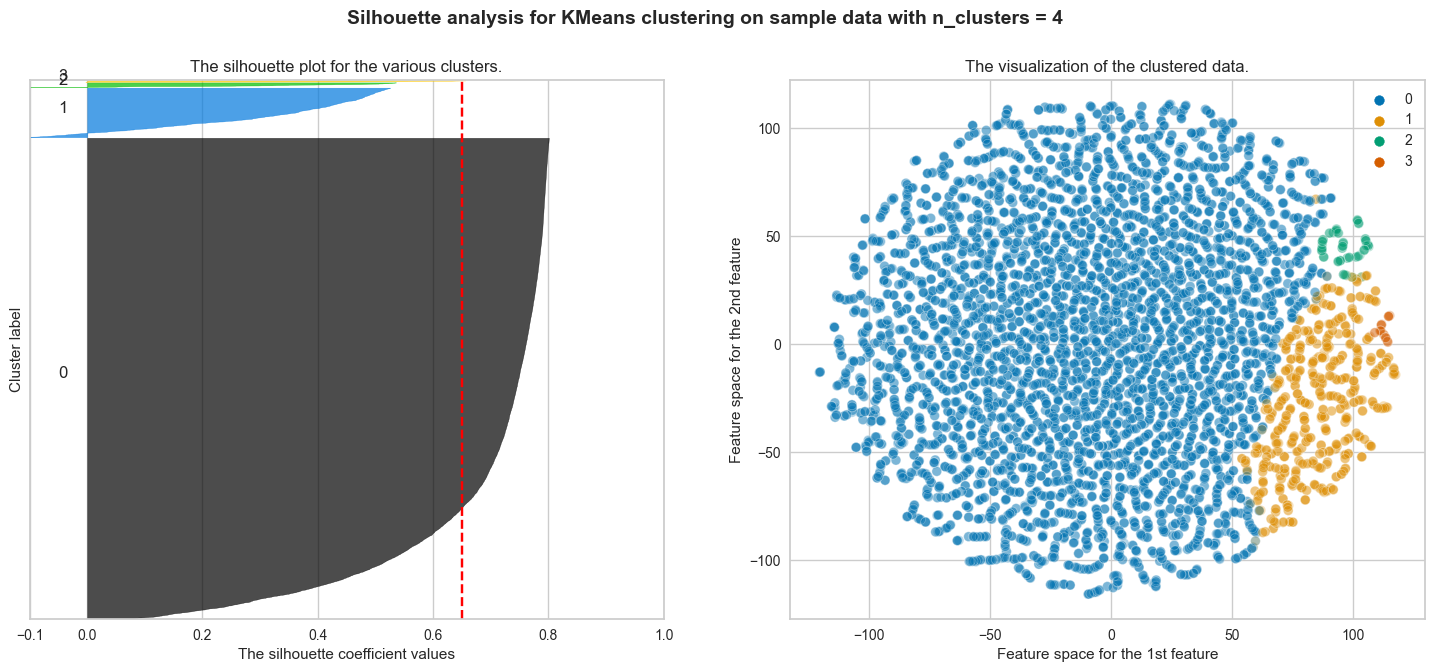

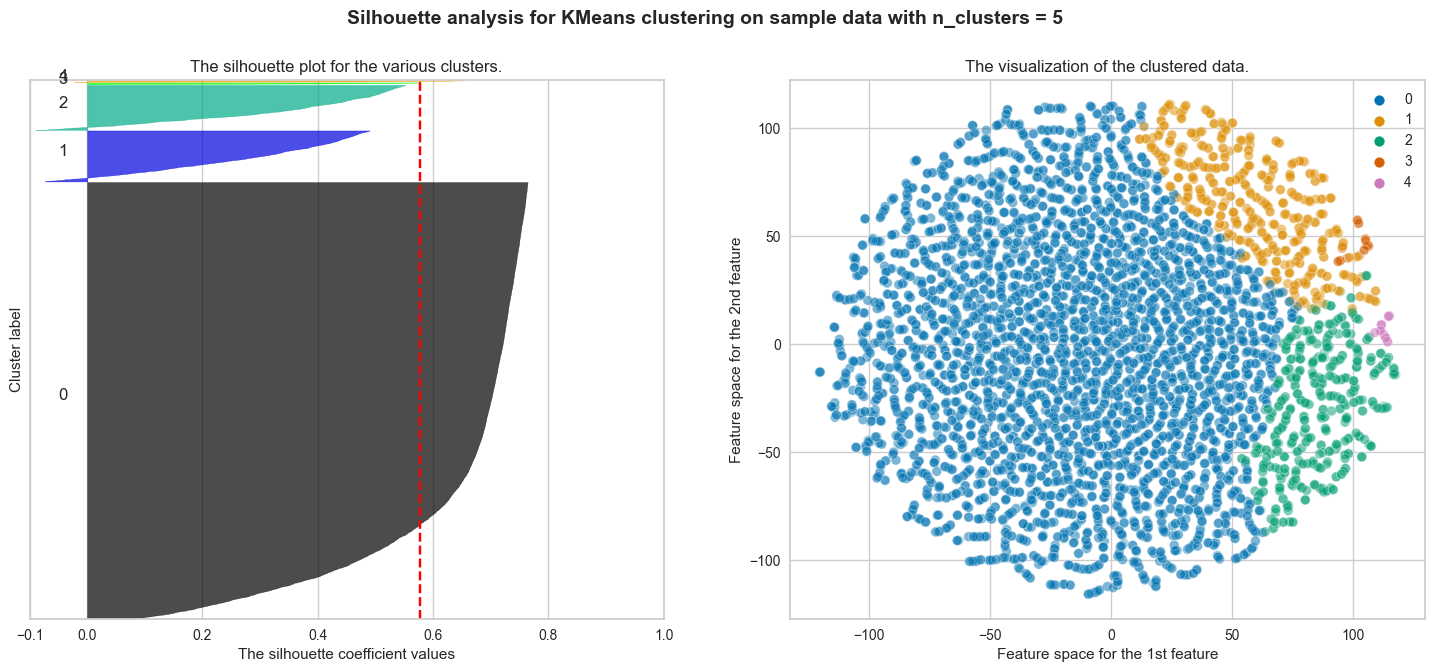

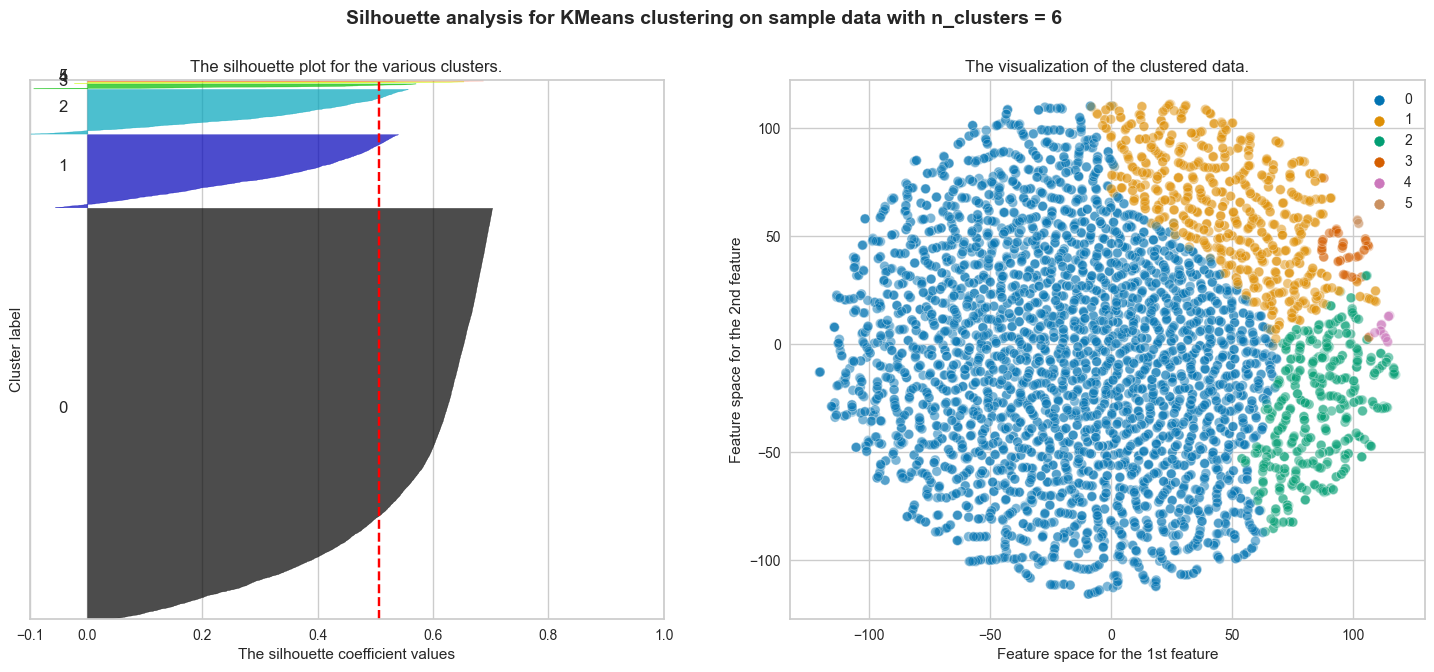

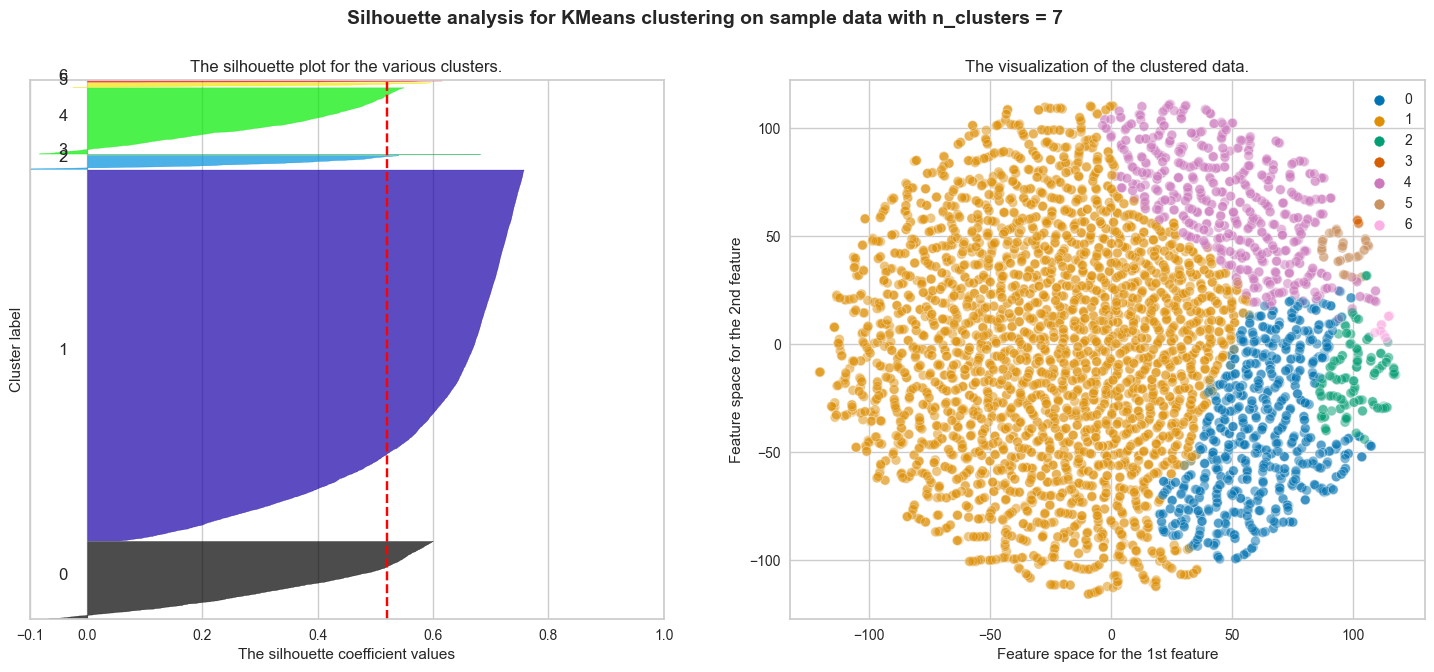

In [66]:
silhouette_plot(KMeans, range(2,8), X, X_TSNE)